### Task 1 - Data Quality and Preparation


In [32]:
import pandas as pd
import numpy as np


apps = pd.read_csv(r'C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\applications.csv')
branches = pd.read_csv(R'C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\branches.csv')
customers = pd.read_csv(r"C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\customers.csv")
defaults = pd.read_csv(r"C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\defaults.csv")
loans = pd.read_csv(r"C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\loans.csv")
txns = pd.read_csv(r"C:\Users\Monjiima\OneDrive\Desktop\Hero_FinCorp_Analysis\Data\transactions.csv")

print("All datasets loaded successfully!")

C:\Users\Monjiima\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (9) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


All datasets loaded successfully!


In [33]:
print("Missing values in Applications:\n", apps.isnull().sum())

print("-" * 30)

apps['Rejection_Reason'] = apps['Rejection_Reason'].fillna('Not Applicable')


customers = customers.dropna(subset=['Customer_ID'])



apps = apps.drop_duplicates()
branches = branches.drop_duplicates()
customers = customers.drop_duplicates()
defaults = defaults.drop_duplicates()
loans = loans.drop_duplicates()
txns = txns.drop_duplicates()

print("Duplicates removed and missing values handled!")

Missing values in Applications:
 Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       12600
Loan_Purpose            0
Source_Channel          0
Processing_Fee          0
Approval_Status         0
Rejection_Reason    70000
dtype: int64
------------------------------
Duplicates removed and missing values handled!


In [34]:

apps['Application_Date'] = pd.to_datetime(apps['Application_Date'])
apps['Approval_Date'] = pd.to_datetime(apps['Approval_Date'])

loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])
loans['Repayment_Start_Date'] = pd.to_datetime(loans['Repayment_Start_Date'])
loans['Repayment_End_Date'] = pd.to_datetime(loans['Repayment_End_Date'])

defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])
txns['Transaction_Date'] = pd.to_datetime(txns['Transaction_Date'])



columns_to_drop = ['Address', 'Contact_Number', 'Email']
customers = customers.drop(columns=columns_to_drop, errors='ignore')


print("Dates standardized and irrelevant columns removed!")
print("-" * 30)
print("Remaining Customer Columns:", customers.columns.tolist())

Dates standardized and irrelevant columns removed!
------------------------------
Remaining Customer Columns: ['Customer_ID', 'Full_Name', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']


In [35]:
def cap_outliers(df, column_name):
   
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    
    df[column_name] = np.where(df[column_name] < lower_bound, lower_bound, df[column_name])
    df[column_name] = np.where(df[column_name] > upper_bound, upper_bound, df[column_name])
    
    return df

loans = cap_outliers(loans, 'Loan_Amount')
loans = cap_outliers(loans, 'Interest_Rate')
defaults = cap_outliers(defaults, 'Default_Amount')

print("Outliers successfully capped!")

Outliers successfully capped!


### Task 2 - Descriptive Analysis

### Distribution of Loan Amount, EMI Amount, and Credit Score.

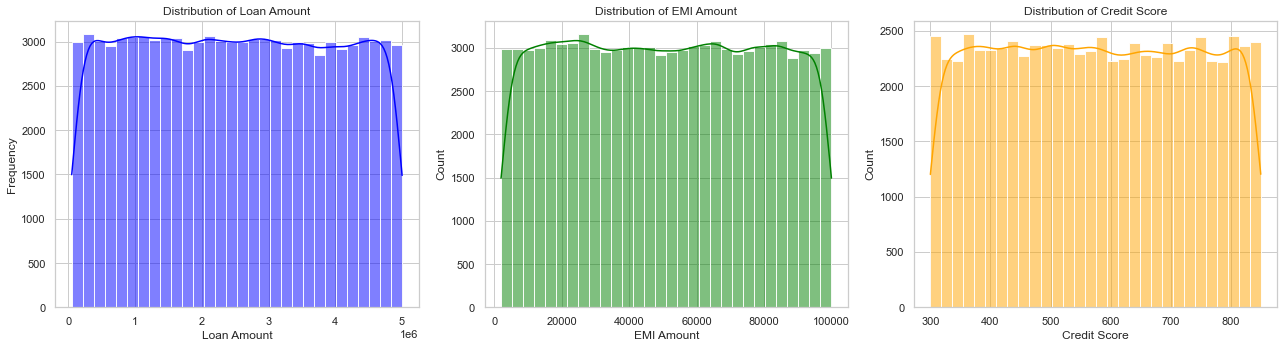

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 5))

# 1st Chart
plt.subplot(1, 3, 1)
sns.histplot(loans['Loan_Amount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

# 2nd Chart
plt.subplot(1, 3, 2)
sns.histplot(loans['EMI_Amount'], bins=30, kde=True, color='green')
plt.title('Distribution of EMI Amount')
plt.xlabel('EMI Amount')

# 3rd Chart
plt.subplot(1, 3, 3)
sns.histplot(customers['Credit_Score'], bins=30, kde=True, color='orange')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')

plt.tight_layout()
plt.show()

### Regional trends in loan disbursement and defaults

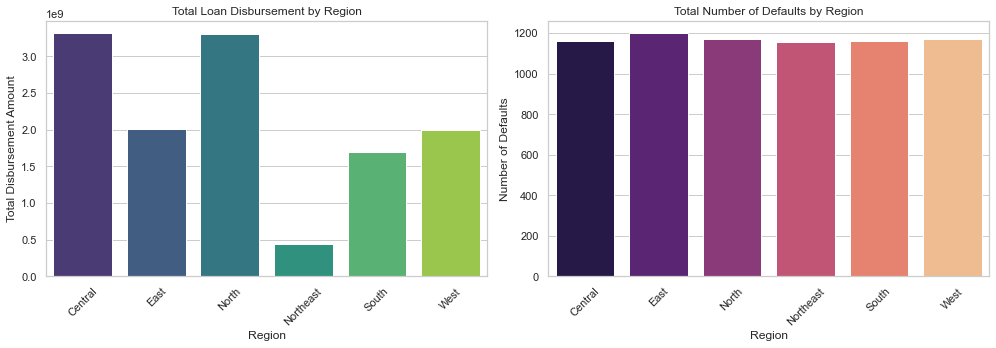

In [37]:

regional_disbursement = branches.groupby('Region')['Loan_Disbursement_Amount'].sum().reset_index()

defaults_with_region = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
regional_defaults = defaults_with_region.groupby('Region')['Default_ID'].count().reset_index()
regional_defaults.rename(columns={'Default_ID': 'Total_Defaults'}, inplace=True)

plt.figure(figsize=(14, 5))

# 1st Chart

plt.subplot(1, 2, 1)
sns.barplot(data=regional_disbursement, x='Region', y='Loan_Disbursement_Amount', palette='viridis')
plt.title('Total Loan Disbursement by Region')
plt.xticks(rotation=45)
plt.ylabel('Total Disbursement Amount')

# 2nd Chart

plt.subplot(1, 2, 2)
sns.barplot(data=regional_defaults, x='Region', y='Total_Defaults', palette='magma')
plt.title('Total Number of Defaults by Region')
plt.xticks(rotation=45)
plt.ylabel('Number of Defaults')

plt.tight_layout()
plt.show()

### Monthly Trends in Approvals and Disbursements

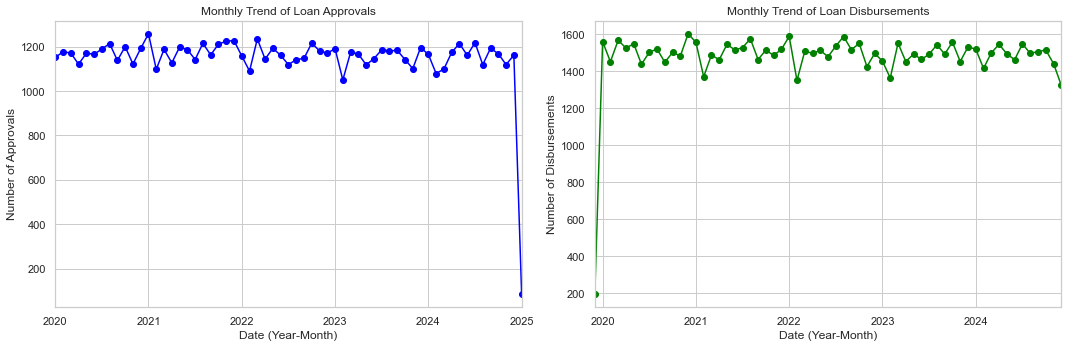

In [38]:
monthly_approvals = apps[apps['Approval_Status'] == 'Approved'].groupby(apps['Approval_Date'].dt.to_period('M')).size()
monthly_disbursals = loans.groupby(loans['Disbursal_Date'].dt.to_period('M')).size()

plt.figure(figsize=(15, 5))

# 1st Chart

plt.subplot(1, 2, 1)
monthly_approvals.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Trend of Loan Approvals')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Number of Approvals')

# 2nd Chart

plt.subplot(1, 2, 2)
monthly_disbursals.plot(kind='line', marker='o', color='green')
plt.title('Monthly Trend of Loan Disbursements')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Number of Disbursements')

plt.tight_layout()
plt.show()

### Task 3 - Default Risk Analysis

### Correlation Between Loan Attributes and Defaults

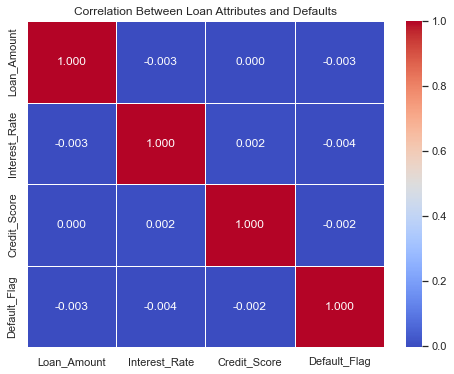

In [39]:
defaulted_loans = defaults['Loan_ID'].unique()

loans['Default_Flag'] = loans['Loan_ID'].apply(lambda x: 1 if x in defaulted_loans else 0)

loan_cust = pd.merge(loans, customers, on='Customer_ID', how='inner')

corr_cols = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
corr_matrix = loan_cust[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Between Loan Attributes and Defaults')
plt.show()

### Pairwise Correlation Analysis

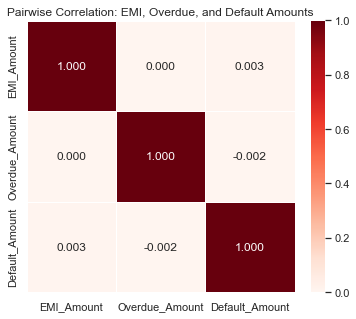

In [40]:
loans_and_defaults = pd.merge(loans, defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

loans_and_defaults['Default_Amount'] = loans_and_defaults['Default_Amount'].fillna(0)

pairwise_cols = ['EMI_Amount', 'Overdue_Amount', 'Default_Amount']
pairwise_corr = loans_and_defaults[pairwise_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(pairwise_corr, annot=True, cmap='Reds', fmt=".3f", linewidths=0.5)
plt.title('Pairwise Correlation: EMI, Overdue, and Default Amounts')
plt.show()

###  Correlation Between Branch Metrics and Defaults


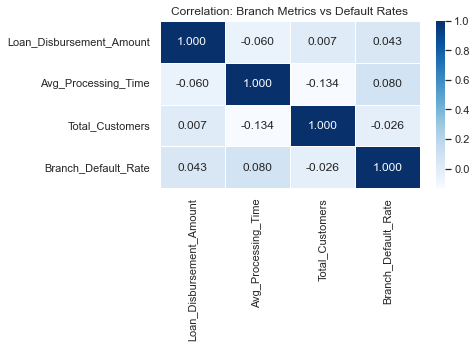

In [41]:
branches['Branch_Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

branch_metrics = [
    'Loan_Disbursement_Amount', 
    'Avg_Processing_Time', 
    'Total_Customers', 
    'Branch_Default_Rate'
]

branch_corr = branches[branch_metrics].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(branch_corr, annot=True, cmap='Blues', fmt=".3f", linewidths=0.5)
plt.title('Correlation: Branch Metrics vs Default Rates')

plt.tight_layout() 
plt.show()

### Task 4 - Branch and Regional Performance


### Branches Ranking

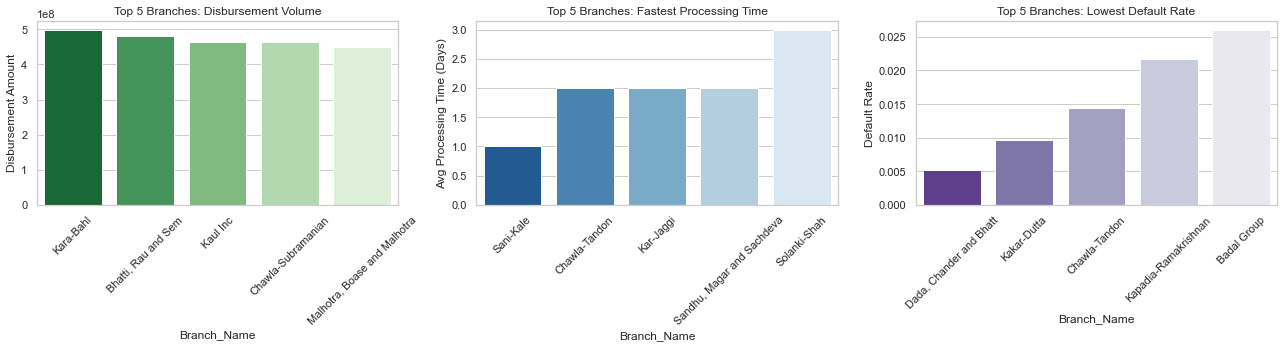

----------------------------------------
Average Recovery Rates by Region:
   Region  Recovery_Rate
  Central       0.447717
Northeast       0.411552
    South       0.409559
    North       0.382243
     West       0.374519
     East       0.357711


In [42]:
branches['Branch_Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

plt.figure(figsize=(18, 5))

# CHART 1: 

top_disb = branches.sort_values(by='Loan_Disbursement_Amount', ascending=False).head(5)
plt.subplot(1, 3, 1)
sns.barplot(data=top_disb, x='Branch_Name', y='Loan_Disbursement_Amount', palette='Greens_r')
plt.title('Top 5 Branches: Disbursement Volume')
plt.xticks(rotation=45)
plt.ylabel('Disbursement Amount')

# CHART 2: 

top_proc = branches.sort_values(by='Avg_Processing_Time', ascending=True).head(5)
plt.subplot(1, 3, 2)
sns.barplot(data=top_proc, x='Branch_Name', y='Avg_Processing_Time', palette='Blues_r')
plt.title('Top 5 Branches: Fastest Processing Time')
plt.xticks(rotation=45)
plt.ylabel('Avg Processing Time (Days)')

# CHART 3: 

top_def = branches.sort_values(by='Branch_Default_Rate', ascending=True).head(5)
plt.subplot(1, 3, 3)
sns.barplot(data=top_def, x='Branch_Name', y='Branch_Default_Rate', palette='Purples_r')
plt.title('Top 5 Branches: Lowest Default Rate')
plt.xticks(rotation=45)
plt.ylabel('Default Rate')

plt.tight_layout()
plt.show()

print("-" * 40)

defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

defaults_with_region = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

regional_recovery = defaults_with_region.groupby('Region')['Recovery_Rate'].mean().reset_index()

regional_recovery = regional_recovery.sort_values(by='Recovery_Rate', ascending=False)

print("Average Recovery Rates by Region:")
print(regional_recovery.to_string(index=False))

### Comparing branch performance across regions


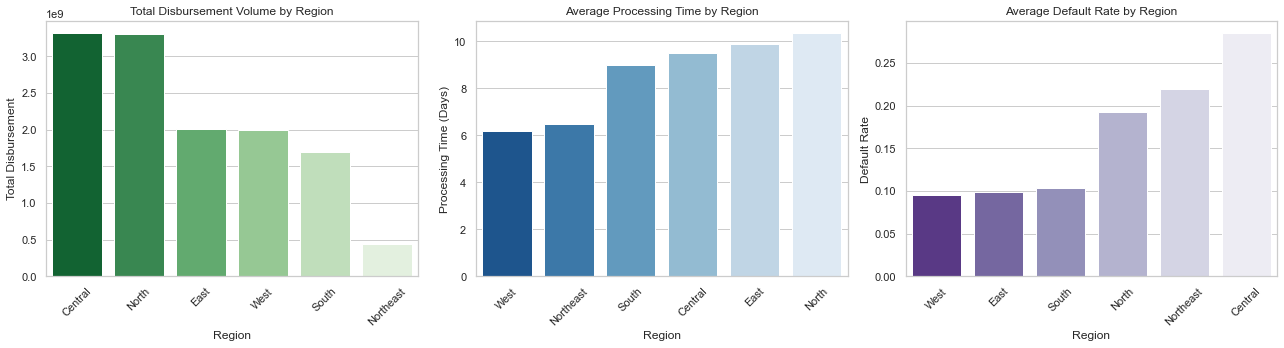

In [139]:
regional_performance = branches.groupby('Region').agg(
    Total_Disbursement=('Loan_Disbursement_Amount', 'sum'),
    Average_Processing_Time=('Avg_Processing_Time', 'mean'),
    Average_Default_Rate=('Branch_Default_Rate', 'mean')
).reset_index()

plt.figure(figsize=(18, 5))

# CHART 1

plt.subplot(1, 3, 1)
sns.barplot(data=regional_performance.sort_values('Total_Disbursement', ascending=False), 
            x='Region', y='Total_Disbursement', palette='Greens_r')
plt.title('Total Disbursement Volume by Region')
plt.xticks(rotation=45)
plt.ylabel('Total Disbursement')

# CHART 2

plt.subplot(1, 3, 2)
sns.barplot(data=regional_performance.sort_values('Average_Processing_Time', ascending=True), 
            x='Region', y='Average_Processing_Time', palette='Blues_r')
plt.title('Average Processing Time by Region')
plt.xticks(rotation=45)
plt.ylabel('Processing Time (Days)')

# CHART 3

plt.subplot(1, 3, 3)
sns.barplot(data=regional_performance.sort_values('Average_Default_Rate', ascending=True), 
            x='Region', y='Average_Default_Rate', palette='Purples_r')
plt.title('Average Default Rate by Region')
plt.xticks(rotation=45)
plt.ylabel('Default Rate')

plt.tight_layout()
plt.show()

### Task 5 - Customer Segmentation


###  Segmenting customers by their income, credit score, and loan status


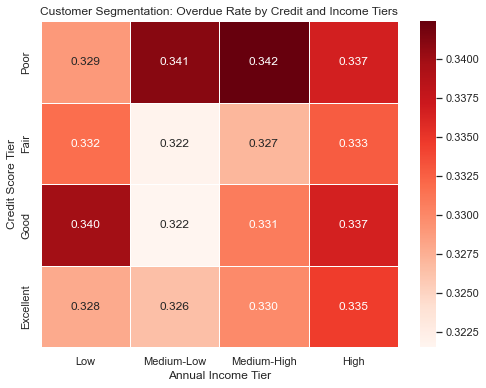

Loan Status Counts by Credit Tier:
----------------------------------------
Loan_Status  Active  Closed  Overdue
Credit_Tier                         
Poor           7483    7452     7598
Fair           7529    7624     7406
Good           7487    7570     7491
Excellent      7551    7438     7371


In [44]:
loan_cust = pd.merge(loans, customers, on='Customer_ID', how='inner')

loan_cust['Income_Tier'] = pd.qcut(loan_cust['Annual_Income'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
loan_cust['Credit_Tier'] = pd.qcut(loan_cust['Credit_Score'], q=4, labels=['Poor', 'Fair', 'Good', 'Excellent'])

loan_cust['Is_Overdue'] = loan_cust['Loan_Status'].apply(lambda x: 1 if x == 'Overdue' else 0)

segment_overdue_rate = loan_cust.groupby(['Credit_Tier', 'Income_Tier'])['Is_Overdue'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(segment_overdue_rate, annot=True, cmap='Reds', fmt=".3f", linewidths=0.5)
plt.title('Customer Segmentation: Overdue Rate by Credit and Income Tiers')
plt.ylabel('Credit Score Tier')
plt.xlabel('Annual Income Tier')
plt.show()

status_by_credit = loan_cust.groupby(['Credit_Tier', 'Loan_Status']).size().unstack()
print("Loan Status Counts by Credit Tier:")
print("-" * 40)
print(status_by_credit)

### Identifing high-risk and high-value customer groups

In [45]:
segment_analysis = loan_cust.groupby(['Credit_Tier', 'Income_Tier']).agg(
    Total_Customers=('Customer_ID', 'count'),
    Average_Loan_Amount=('Loan_Amount', 'mean'),
    Overdue_Rate=('Is_Overdue', 'mean')
).reset_index()

high_risk = segment_analysis.sort_values(by='Overdue_Rate', ascending=False).head(3)

high_value = segment_analysis.sort_values(by=['Overdue_Rate', 'Average_Loan_Amount'], ascending=[True, False]).head(3)

print("TOP 3 HIGH-RISK CUSTOMER GROUPS")
print("-" * 50)
print(high_risk.to_string(index=False))
print("\n" + "=" * 50 + "\n")
print("TOP 3 HIGH-VALUE CUSTOMER GROUPS")
print("-" * 50)
print(high_value.to_string(index=False))

TOP 3 HIGH-RISK CUSTOMER GROUPS
--------------------------------------------------
Credit_Tier Income_Tier  Total_Customers  Average_Loan_Amount  Overdue_Rate
       Poor Medium-High             5631         2.511800e+06      0.342390
       Poor  Medium-Low             5567         2.491574e+06      0.340938
       Good         Low             5520         2.506209e+06      0.339855


TOP 3 HIGH-VALUE CUSTOMER GROUPS
--------------------------------------------------
Credit_Tier Income_Tier  Total_Customers  Average_Loan_Amount  Overdue_Rate
       Good  Medium-Low             5570         2.537639e+06      0.321544
       Fair  Medium-Low             5773         2.512022e+06      0.321843
  Excellent  Medium-Low             5590         2.506972e+06      0.326476


### Analysing repayment behavior across segments

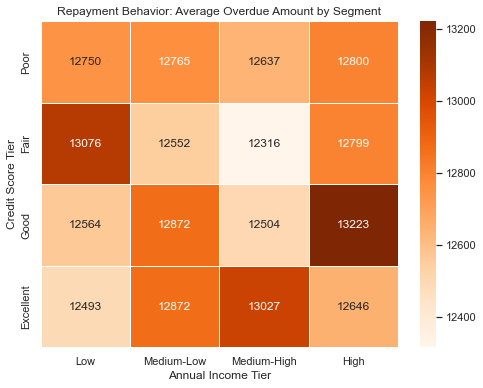

Percentage of Transactions that are Penalties (by Credit Tier):
------------------------------------------------------------
Credit_Tier
Poor         49.96%
Fair         50.06%
Good         50.05%
Excellent    50.21%
dtype: object


In [46]:
segment_repayment = loan_cust.groupby(['Credit_Tier', 'Income_Tier'])['Overdue_Amount'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(segment_repayment, annot=True, cmap='Oranges', fmt=".0f", linewidths=0.5)
plt.title('Repayment Behavior: Average Overdue Amount by Segment')
plt.ylabel('Credit Score Tier')
plt.xlabel('Annual Income Tier')
plt.show()

txn_segment = pd.merge(txns, loan_cust[['Loan_ID', 'Credit_Tier', 'Income_Tier']], on='Loan_ID', how='inner')

penalty_rates = txn_segment[txn_segment['Payment_Type'] == 'Penalty'].groupby('Credit_Tier').size() / txn_segment.groupby('Credit_Tier').size() * 100

print("Percentage of Transactions that are Penalties (by Credit Tier):")
print("-" * 60)
print(penalty_rates.round(2).astype(str) + '%')

### Task 6 - Advanced Statistical Analysis


### Correlation Analysis for Default Risks

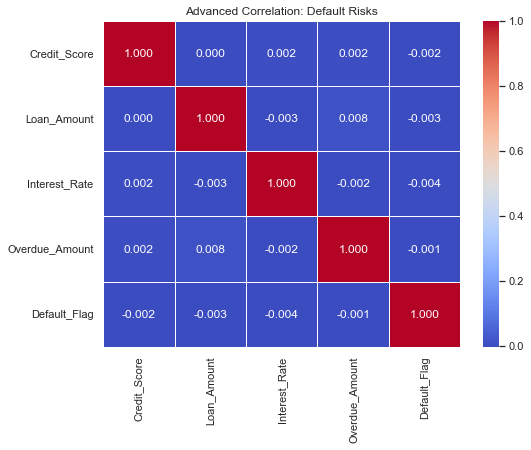

In [145]:

advanced_cols = ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Flag']

advanced_corr = loan_cust[advanced_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(advanced_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Advanced Correlation: Default Risks')
plt.show()

### Pairwise Correlation Heatmap

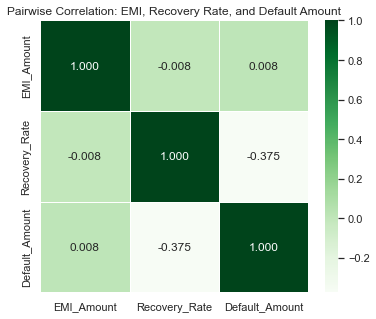

In [48]:

loans_and_defaults = pd.merge(loans, defaults, on='Loan_ID', how='inner')

loans_and_defaults['Recovery_Rate'] = loans_and_defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)

pairwise_cols_adv = ['EMI_Amount', 'Recovery_Rate', 'Default_Amount']

pairwise_corr_adv = loans_and_defaults[pairwise_cols_adv].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(pairwise_corr_adv, annot=True, cmap='Greens', fmt=".3f", linewidths=0.5)
plt.title('Pairwise Correlation: EMI, Recovery Rate, and Default Amount')
plt.show()

### Branch-Level Correlation

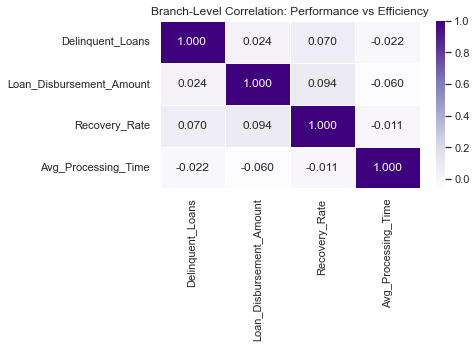

In [146]:

defaults['Recovery_Rate'] = defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)

defaults_with_region = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
regional_recovery = defaults_with_region.groupby('Region')['Recovery_Rate'].mean().reset_index()

branches_with_recovery = pd.merge(branches, regional_recovery, on='Region', how='left')

branch_metrics_adv = [
    'Delinquent_Loans', 
    'Loan_Disbursement_Amount', 
    'Recovery_Rate', 
    'Avg_Processing_Time'
]

branch_corr_adv = branches_with_recovery[branch_metrics_adv].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(branch_corr_adv, annot=True, cmap='Purples', fmt=".3f", linewidths=0.5)
plt.title('Branch-Level Correlation: Performance vs Efficiency')

plt.tight_layout()
plt.show()

### Task 7 - Transaction and Recovery Analysis

### Analysing Penalty Payments and Overdue Trends

Total Number of Transactions by Type:
----------------------------------------
Penalty    247844
EMI        247156
Name: Payment_Type, dtype: int64


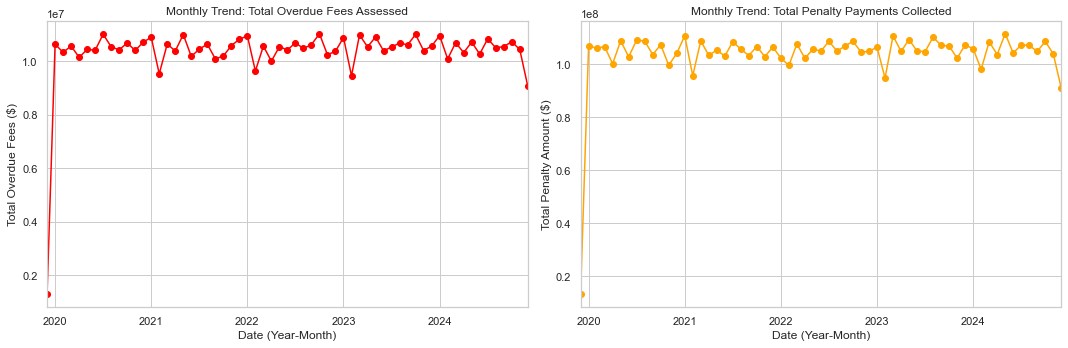

In [147]:

payment_breakdown = txns['Payment_Type'].value_counts()
print("Total Number of Transactions by Type:")
print("-" * 40)
print(payment_breakdown)

monthly_overdue = txns.groupby(txns['Transaction_Date'].dt.to_period('M'))['Overdue_Fee'].sum()

monthly_penalties = txns[txns['Payment_Type'] == 'Penalty'].groupby(txns['Transaction_Date'].dt.to_period('M'))['Amount'].sum()


plt.figure(figsize=(15, 5))

# CHART 1

plt.subplot(1, 2, 1)
monthly_overdue.plot(kind='line', color='red', marker='o')
plt.title('Monthly Trend: Total Overdue Fees Assessed')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Total Overdue Fees ($)')

# CHART 2

plt.subplot(1, 2, 2)
monthly_penalties.plot(kind='line', color='orange', marker='o')
plt.title('Monthly Trend: Total Penalty Payments Collected')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Total Penalty Amount ($)')

plt.tight_layout()
plt.show()

### Evaluating recovery rates by Default_Reason and Legal_Action.


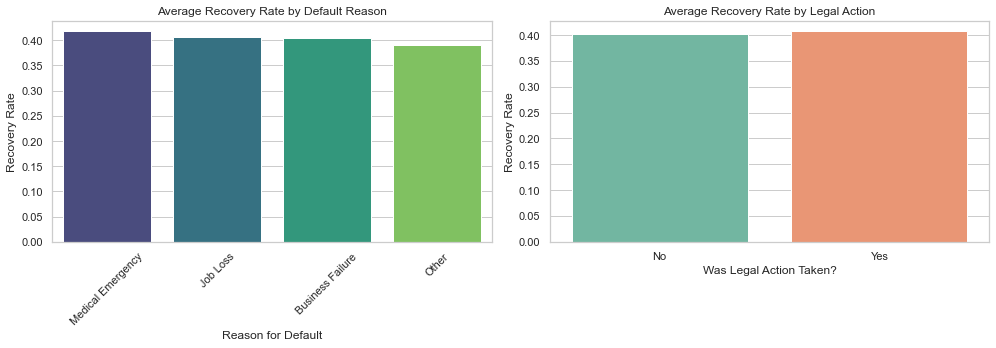

Impact of Legal Action on Recovery Rates:
--------------------------------------------------
Legal Action No: 40.18% recovered on average.
Legal Action Yes: 40.74% recovered on average.


In [149]:

defaults['Recovery_Rate'] = defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)


recovery_by_reason = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().reset_index()


recovery_by_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()


plt.figure(figsize=(14, 5))

# CHART 1

plt.subplot(1, 2, 1)


sns.barplot(data=recovery_by_reason.sort_values('Recovery_Rate', ascending=False), 
            x='Default_Reason', y='Recovery_Rate', palette='viridis')
plt.title('Average Recovery Rate by Default Reason')
plt.ylabel('Recovery Rate')
plt.xlabel('Reason for Default')
plt.xticks(rotation=45)

# CHART 2

plt.subplot(1, 2, 2)
sns.barplot(data=recovery_by_legal, x='Legal_Action', y='Recovery_Rate', palette='Set2')
plt.title('Average Recovery Rate by Legal Action')
plt.ylabel('Recovery Rate')
plt.xlabel('Was Legal Action Taken?')

plt.tight_layout()
plt.show()



print("Impact of Legal Action on Recovery Rates:")
print("-" * 50)
for index, row in recovery_by_legal.iterrows():
    print(f"Legal Action {row['Legal_Action']}: {row['Recovery_Rate']*100:.2f}% recovered on average.")

### Comparing recovery rates across regions and branches

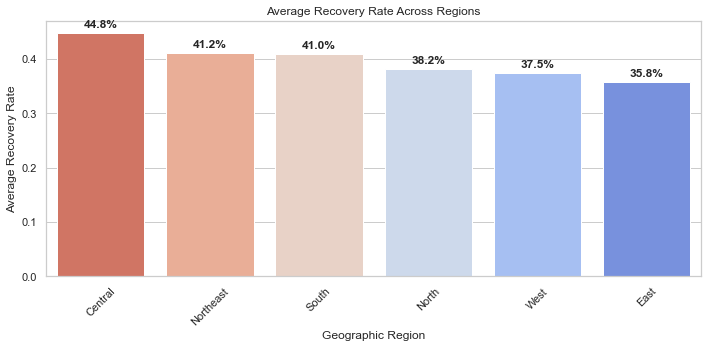

In [150]:

defaults['Recovery_Rate'] = defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)


defaults_with_region = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')


regional_recovery = defaults_with_region.groupby('Region')['Recovery_Rate'].mean().reset_index()


regional_recovery = regional_recovery.sort_values(by='Recovery_Rate', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(data=regional_recovery, x='Region', y='Recovery_Rate', palette='coolwarm_r')

plt.title('Average Recovery Rate Across Regions')
plt.ylabel('Average Recovery Rate')
plt.xlabel('Geographic Region')
plt.xticks(rotation=45)


for index, value in enumerate(regional_recovery['Recovery_Rate']):
    plt.text(index, value + 0.01, f'{value*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Task 8 - EMI Analysis

### Analyze the relationship between EMI amounts and default probabilities.

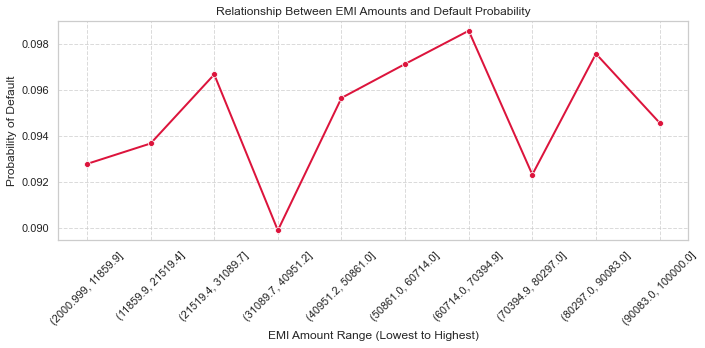

In [151]:

defaulted_ids = defaults['Loan_ID'].unique()
loans['Default_Flag'] = loans['Loan_ID'].apply(lambda x: 1 if x in defaulted_ids else 0)


loans['EMI_Bucket'] = pd.qcut(loans['EMI_Amount'], q=10)


emi_default_prob = loans.groupby('EMI_Bucket')['Default_Flag'].mean().reset_index()

emi_default_prob['EMI_Bucket_Str'] = emi_default_prob['EMI_Bucket'].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(data=emi_default_prob, x='EMI_Bucket_Str', y='Default_Flag', marker='o', color='crimson', linewidth=2)

plt.title('Relationship Between EMI Amounts and Default Probability')
plt.xlabel('EMI Amount Range (Lowest to Highest)')
plt.ylabel('Probability of Default')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Identifing thresholds for EMI amounts where defaults are most likely

HIGH RISK EMI THRESHOLDS
Company Average Default Rate: 9.49%
------------------------------------------------------------
The following EMI ranges exceed the average default risk:
    EMI_Bucket_Str  Default_Flag
(21519.4, 31089.7]      0.096667
(40951.2, 50861.0]      0.095645
(50861.0, 60714.0]      0.097122
(60714.0, 70394.9]      0.098567
(80297.0, 90083.0]      0.097566


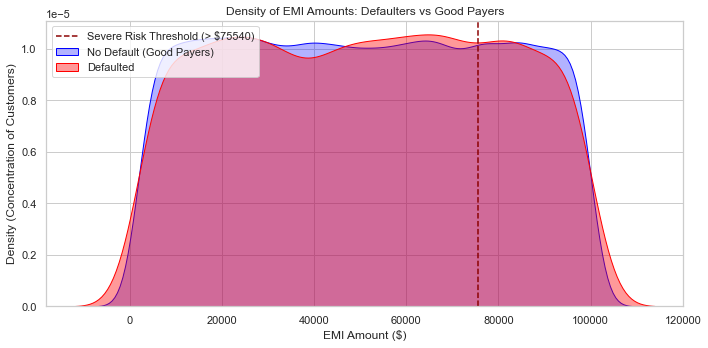

In [152]:

avg_default_rate = loans['Default_Flag'].mean()

risky_emis = emi_default_prob[emi_default_prob['Default_Flag'] > avg_default_rate]

print("HIGH RISK EMI THRESHOLDS")
print(f"Company Average Default Rate: {avg_default_rate*100:.2f}%")
print("-" * 60)
print("The following EMI ranges exceed the average default risk:")
print(risky_emis[['EMI_Bucket_Str', 'Default_Flag']].to_string(index=False))


plt.figure(figsize=(10, 5))


sns.kdeplot(data=loans[loans['Default_Flag'] == 0], x='EMI_Amount', 
            label='No Default (Good Payers)', color='blue', fill=True, alpha=0.3)


sns.kdeplot(data=loans[loans['Default_Flag'] == 1], x='EMI_Amount', 
            label='Defaulted', color='red', fill=True, alpha=0.4)

severe_threshold = loans[loans['Default_Flag'] == 1]['EMI_Amount'].quantile(0.75)
plt.axvline(severe_threshold, color='darkred', linestyle='--', 
            label=f'Severe Risk Threshold (> ${severe_threshold:.0f})')

plt.title('Density of EMI Amounts: Defaulters vs Good Payers')
plt.xlabel('EMI Amount ($)')
plt.ylabel('Density (Concentration of Customers)')
plt.legend()

plt.tight_layout()
plt.show()

### Comparing EMI trends across loan types

In [56]:
print(loans.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Default_Flag', 'EMI_Bucket'],
      dtype='object')


In [60]:
print(apps.columns)

Index(['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date',
       'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee',
       'Approval_Status', 'Rejection_Reason'],
      dtype='object')


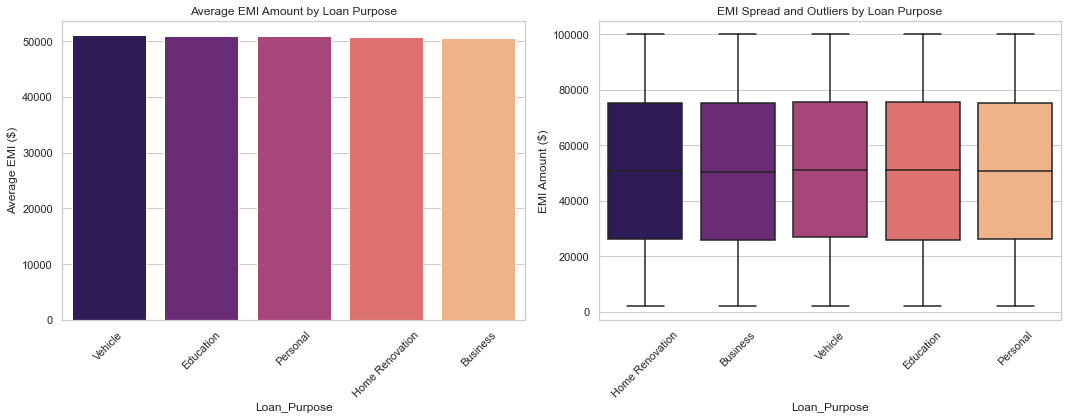

Average EMI by Loan Purpose:
-----------------------------------
   Loan_Purpose   EMI_Amount
        Vehicle 51107.317521
      Education 50941.563688
       Personal 50890.346147
Home Renovation 50775.452007
       Business 50628.547454


In [153]:

loans_with_type = pd.merge(loans, apps[['Customer_ID', 'Loan_Purpose']], on='Customer_ID', how='inner')

avg_emi_by_type = loans_with_type.groupby('Loan_Purpose')['EMI_Amount'].mean().reset_index()
avg_emi_by_type = avg_emi_by_type.sort_values(by='EMI_Amount', ascending=False)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=avg_emi_by_type, x='Loan_Purpose', y='EMI_Amount', palette='magma')
plt.title('Average EMI Amount by Loan Purpose')
plt.xticks(rotation=45)
plt.ylabel('Average EMI ($)')

plt.subplot(1, 2, 2)
sns.boxplot(data=loans_with_type, x='Loan_Purpose', y='EMI_Amount', palette='magma')
plt.title('EMI Spread and Outliers by Loan Purpose')
plt.xticks(rotation=45)
plt.ylabel('EMI Amount ($)')

plt.tight_layout()
plt.show()


print("Average EMI by Loan Purpose:")
print("-" * 35)
print(avg_emi_by_type.to_string(index=False))


### Task 9 - Loan Application Insights



### Calculating approval and rejection rates for loan applications.

Loan Application Status Rates:
----------------------------------------
Approved: 84.75% (70000 total applications)
Rejected: 15.25% (12600 total applications)


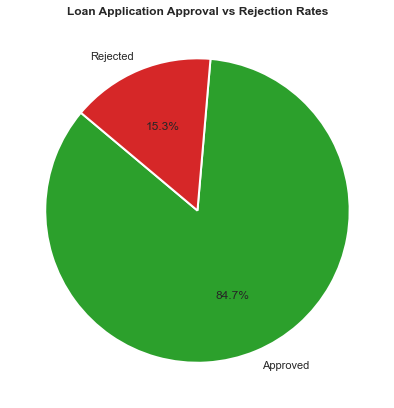

In [154]:

status_counts = apps['Approval_Status'].value_counts()

status_rates = apps['Approval_Status'].value_counts(normalize=True) * 100

print("Loan Application Status Rates:")
print("-" * 40)
for status, rate in status_rates.items():
    
    print(f"{status}: {rate:.2f}% ({status_counts[status]} total applications)")


plt.figure(figsize=(7, 7))


colors = ['#2ca02c', '#d62728', '#7f7f7f'] 

plt.pie(status_rates, labels=status_rates.index, autopct='%1.1f%%', 
        startangle=140, colors=colors[:len(status_rates)], 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Loan Application Approval vs Rejection Rates', fontweight='bold')
plt.show()

### Identifing the most common reasons for loan rejection

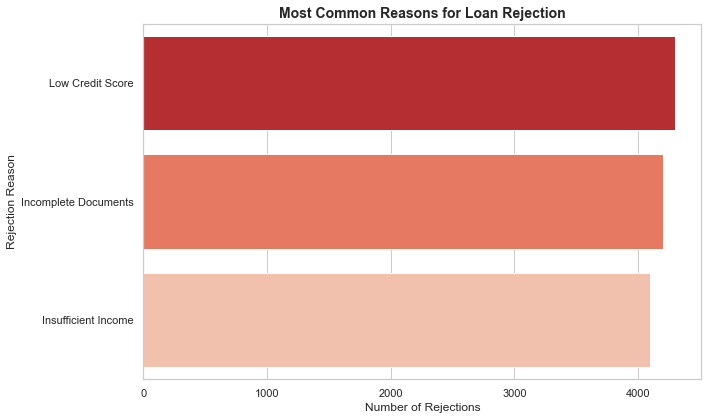

Top Reasons for Loan Rejection:
---------------------------------------------
Low Credit Score: 4297 applications (34.1%)
Incomplete Documents: 4204 applications (33.4%)
Insufficient Income: 4099 applications (32.5%)


In [156]:

rejected_apps = apps[apps['Approval_Status'] == 'Rejected']

rejection_counts = rejected_apps['Rejection_Reason'].value_counts().reset_index()
rejection_counts.columns = ['Rejection_Reason', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=rejection_counts, x='Count', y='Rejection_Reason', palette='Reds_r')

plt.title('Most Common Reasons for Loan Rejection', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rejections')
plt.ylabel('Rejection Reason')

plt.tight_layout()
plt.show()

print("Top Reasons for Loan Rejection:")
print("-" * 45)

rejection_percentages = rejected_apps['Rejection_Reason'].value_counts(normalize=True) * 100
for reason, count in rejected_apps['Rejection_Reason'].value_counts().items():
    pct = rejection_percentages[reason]
    print(f"{reason}: {count} applications ({pct:.1f}%)")

### Processing Fees: Approved vs Rejected

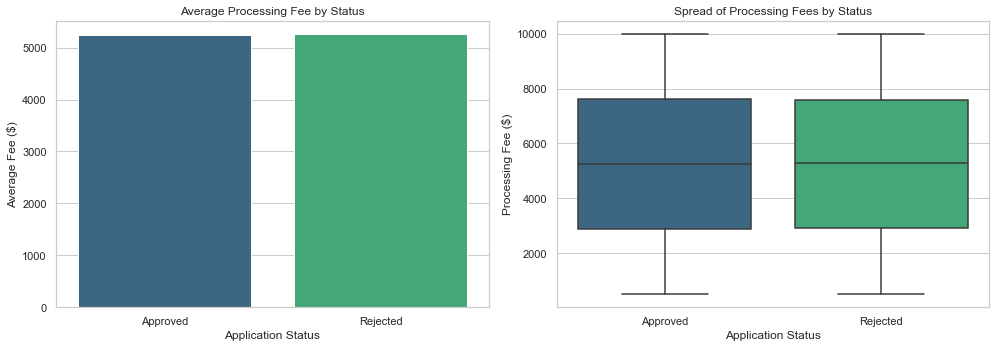

💰 Average Processing Fee by Status:
-----------------------------------
Approved: $5252.40
Rejected: $5255.14


In [63]:
finished_apps = apps[apps['Approval_Status'].isin(['Approved', 'Rejected'])]

avg_fee_by_status = finished_apps.groupby('Approval_Status')['Processing_Fee'].mean().reset_index()

plt.figure(figsize=(14, 5))

# CHART 1

plt.subplot(1, 2, 1)
sns.barplot(data=avg_fee_by_status, x='Approval_Status', y='Processing_Fee', palette='viridis')
plt.title('Average Processing Fee by Status')
plt.ylabel('Average Fee ($)')
plt.xlabel('Application Status')

# CHART 2

plt.subplot(1, 2, 2)
sns.boxplot(data=finished_apps, x='Approval_Status', y='Processing_Fee', palette='viridis')
plt.title('Spread of Processing Fees by Status')
plt.ylabel('Processing Fee ($)')
plt.xlabel('Application Status')

plt.tight_layout()
plt.show()



print("Average Processing Fee by Status:")
print("-" * 35)
for index, row in avg_fee_by_status.iterrows():
    print(f"{row['Approval_Status']}: ${row['Processing_Fee']:.2f}")

## Task 10 - Recovery Effectiveness


### Overall Recovery Ratio

OVERALL RECOVERY EFFECTIVENESS 📈
---------------------------------------------
Total Default Amount:   $476,807,757.00
Total Recovered Amount: $115,919,813.00
Overall Recovery Ratio: 24.31%
---------------------------------------------


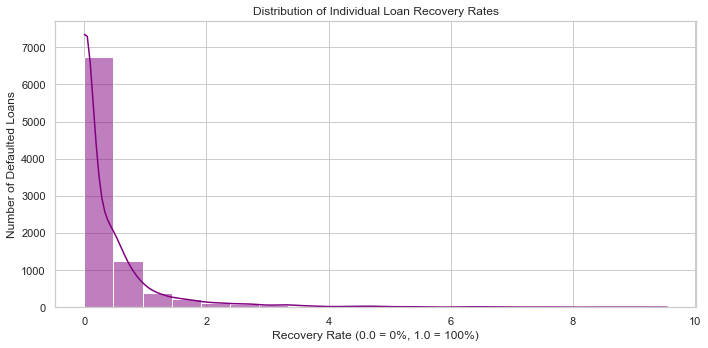

In [157]:
total_default = defaults['Default_Amount'].sum()
total_recovery = defaults['Recovery_Amount'].sum()

overall_recovery_ratio = (total_recovery / total_default) * 100

print("OVERALL RECOVERY EFFECTIVENESS 📈")
print("-" * 45)
print(f"Total Default Amount:   ${total_default:,.2f}")
print(f"Total Recovered Amount: ${total_recovery:,.2f}")
print(f"Overall Recovery Ratio: {overall_recovery_ratio:.2f}%")
print("-" * 45)

defaults['Recovery_Rate'] = defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)

plt.figure(figsize=(10, 5))
sns.histplot(data=defaults, x='Recovery_Rate', bins=20, kde=True, color='purple')

plt.title('Distribution of Individual Loan Recovery Rates')
plt.xlabel('Recovery Rate (0.0 = 0%, 1.0 = 100%)')
plt.ylabel('Number of Defaulted Loans')

plt.tight_layout()
plt.show()

### Recovery Rates: With vs. Without Legal Action

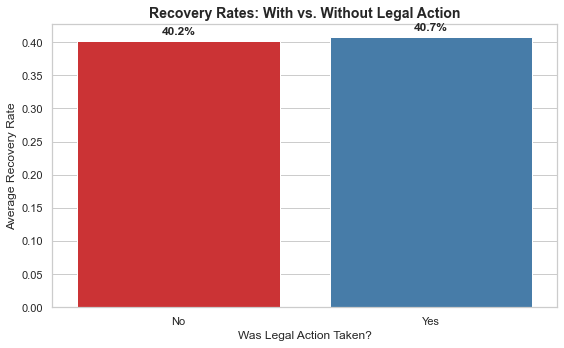

Recovery Rates by Legal Action:
-----------------------------------
Legal Action 'No': 40.18% average recovery
Legal Action 'Yes': 40.74% average recovery


In [158]:


recovery_by_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=recovery_by_legal, x='Legal_Action', y='Recovery_Rate', palette='Set1')

plt.title('Recovery Rates: With vs. Without Legal Action', fontweight='bold', fontsize=14)
plt.xlabel('Was Legal Action Taken?', fontsize=12)
plt.ylabel('Average Recovery Rate', fontsize=12)

for index, value in enumerate(recovery_by_legal['Recovery_Rate']):
    plt.text(index, value + 0.01, f'{value*100:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("Recovery Rates by Legal Action:")
print("-" * 35)
for index, row in recovery_by_legal.iterrows():
    print(f"Legal Action '{row['Legal_Action']}': {row['Recovery_Rate']*100:.2f}% average recovery")

### Analyzing branch-wise recovery performance.

In [72]:
print("Customers columns:", customers.columns.tolist())
print("Loans columns:", loans.columns.tolist())
print("Apps columns:", apps.columns.tolist())
try:
    print("Branches columns:", branches.columns.tolist())
except NameError:
    print("No 'branches' dataset loaded.")

Customers columns: ['Customer_ID', 'Full_Name', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']
Loans columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'EMI_Bucket']
Apps columns: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason']
Branches columns: ['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count', 'Branch_Default_Rate']


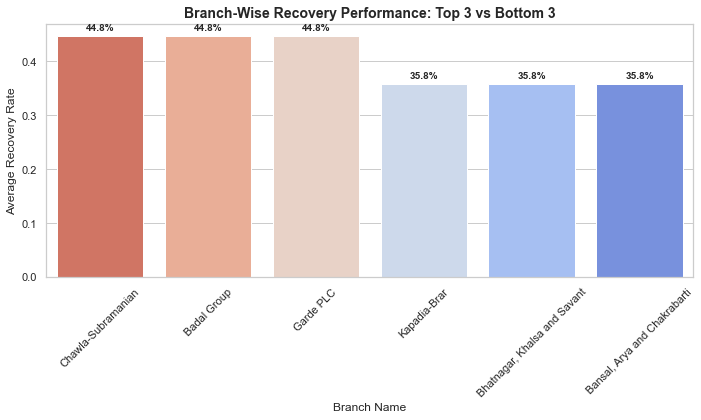

TOP 3 PERFORMING BRANCHES (Collections):
---------------------------------------------
       Branch_Name  Recovery_Rate
Chawla-Subramanian       0.447717
       Badal Group       0.447717
         Garde PLC       0.447717

 BOTTOM 3 PERFORMING BRANCHES (Collections):
---------------------------------------------
                 Branch_Name  Recovery_Rate
                Kapadia-Brar       0.357711
Bhatnagar, Khalsa and Savant       0.357711
Bansal, Arya and Chakrabarti       0.357711


In [159]:
 defaults['Recovery_Rate'] = defaults.apply(
    lambda row: row['Recovery_Amount'] / row['Default_Amount'] if row['Default_Amount'] > 0 else 0, 
    axis=1
)

def_cust = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

defaults_with_branch = pd.merge(def_cust, branches[['Region', 'Branch_Name']], on='Region', how='inner')

branch_recovery = defaults_with_branch.groupby('Branch_Name')['Recovery_Rate'].mean().reset_index()

branch_recovery = branch_recovery.sort_values(by='Recovery_Rate', ascending=False)

top_branches = branch_recovery.head(3)
bottom_branches = branch_recovery.tail(3)
best_and_worst = pd.concat([top_branches, bottom_branches])

plt.figure(figsize=(10, 6))
sns.barplot(data=best_and_worst, x='Branch_Name', y='Recovery_Rate', palette='coolwarm_r')

plt.title('Branch-Wise Recovery Performance: Top 3 vs Bottom 3', fontweight='bold', fontsize=14)
plt.xlabel('Branch Name', fontsize=12)
plt.ylabel('Average Recovery Rate', fontsize=12)
plt.xticks(rotation=45)

for index, value in enumerate(best_and_worst['Recovery_Rate']):
    plt.text(index, value + 0.01, f'{value*100:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("TOP 3 PERFORMING BRANCHES (Collections):")
print("-" * 45)
print(top_branches.to_string(index=False))
print("\n BOTTOM 3 PERFORMING BRANCHES (Collections):")
print("-" * 45)
print(bottom_branches.to_string(index=False))

## Task 11 - Loan Disbursement Eﬃciency


### Analyzing the time from application to loan disbursement and identify bottlenecks

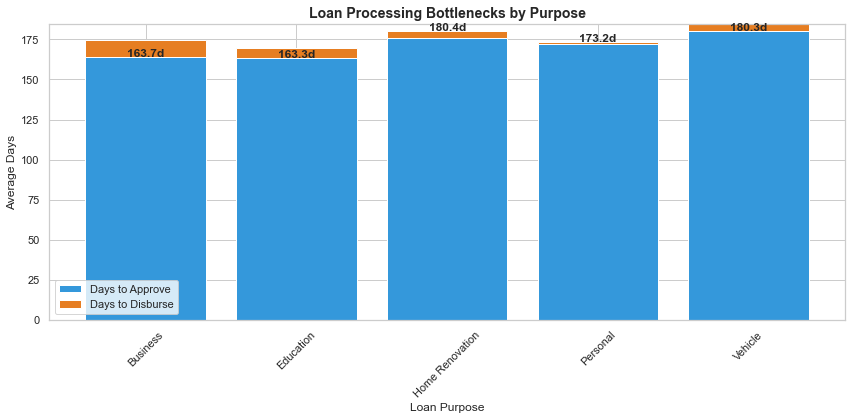

Efficiency Metrics by Loan Category:
--------------------------------------------------
   Loan_Purpose  App_to_Approval  Approval_to_Disbursal
       Business       174.435870             -10.710611
      Education       169.675376              -6.327774
Home Renovation       175.803845               4.548235
       Personal       172.167480               1.025534
        Vehicle       184.805873              -4.536776


In [160]:

eff_data = pd.merge(apps[apps['Approval_Status'] == 'Approved'], 
                    loans[['Loan_ID', 'Disbursal_Date']], 
                    on='Loan_ID', how='inner')

eff_data['Application_Date'] = pd.to_datetime(eff_data['Application_Date'])
eff_data['Approval_Date'] = pd.to_datetime(eff_data['Approval_Date'])
eff_data['Disbursal_Date'] = pd.to_datetime(eff_data['Disbursal_Date'])

eff_data['App_to_Approval'] = (eff_data['Approval_Date'] - eff_data['Application_Date']).dt.days
eff_data['Approval_to_Disbursal'] = (eff_data['Disbursal_Date'] - eff_data['Approval_Date']).dt.days

bottleneck_summary = eff_data.groupby('Loan_Purpose')[['App_to_Approval', 'Approval_to_Disbursal']].mean().reset_index()

plt.figure(figsize=(12, 6))

p1 = plt.bar(bottleneck_summary['Loan_Purpose'], bottleneck_summary['App_to_Approval'], label='Days to Approve', color='#3498db')
p2 = plt.bar(bottleneck_summary['Loan_Purpose'], bottleneck_summary['Approval_to_Disbursal'], 
             bottom=bottleneck_summary['App_to_Approval'], label='Days to Disburse', color='#e67e22')

plt.title('Loan Processing Bottlenecks by Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose')
plt.ylabel('Average Days')
plt.xticks(rotation=45)
plt.legend()

for i in range(len(bottleneck_summary)):
    total = bottleneck_summary['App_to_Approval'][i] + bottleneck_summary['Approval_to_Disbursal'][i]
    plt.text(i, total + 0.5, f'{total:.1f}d', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Efficiency Metrics by Loan Category:")
print("-" * 50)
print(bottleneck_summary.to_string(index=False))

### Comparing average processing times across branches

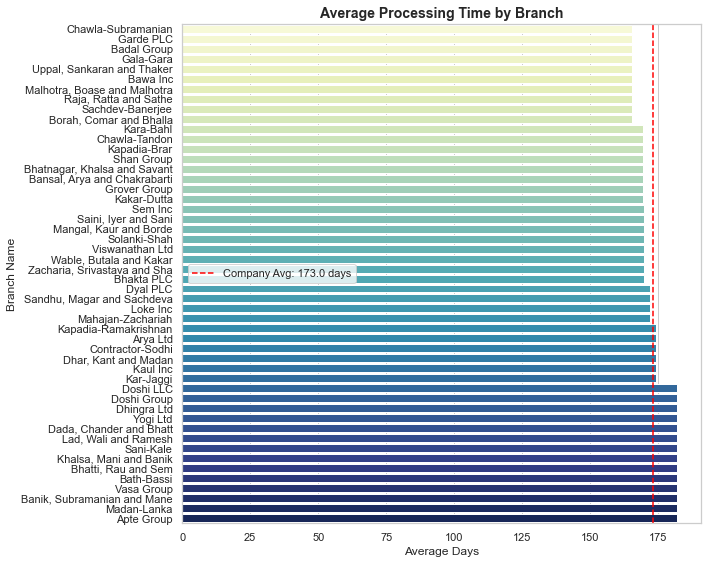

Fastest Branch: Chawla-Subramanian (165.5 days)
Slowest Branch: Apte Group (181.8 days)


In [162]:

approved_apps = apps[apps['Approval_Status'] == 'Approved'].copy()

eff_data = pd.merge(approved_apps, loans[['Loan_ID', 'Disbursal_Date']], on='Loan_ID', how='inner')

eff_with_cust = pd.merge(eff_data, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
eff_with_branch = pd.merge(eff_with_cust, branches[['Region', 'Branch_Name']], on='Region', how='inner')

eff_with_branch['Application_Date'] = pd.to_datetime(eff_with_branch['Application_Date'])
eff_with_branch['Disbursal_Date'] = pd.to_datetime(eff_with_branch['Disbursal_Date'])

eff_with_branch['Total_Time_Days'] = (eff_with_branch['Disbursal_Date'] - eff_with_branch['Application_Date']).dt.days

branch_efficiency = eff_with_branch.groupby('Branch_Name')['Total_Time_Days'].mean().reset_index()
branch_efficiency = branch_efficiency.sort_values(by='Total_Time_Days')

plt.figure(figsize=(10, 8))
sns.barplot(data=branch_efficiency, x='Total_Time_Days', y='Branch_Name', palette='YlGnBu')

company_avg = branch_efficiency['Total_Time_Days'].mean()
plt.axvline(company_avg, color='red', linestyle='--', label=f'Company Avg: {company_avg:.1f} days')

plt.title('Average Processing Time by Branch', fontsize=14, fontweight='bold')
plt.xlabel('Average Days')
plt.ylabel('Branch Name')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fastest Branch: {branch_efficiency.iloc[0]['Branch_Name']} ({branch_efficiency.iloc[0]['Total_Time_Days']:.1f} days)")
print(f"Slowest Branch: {branch_efficiency.iloc[-1]['Branch_Name']} ({branch_efficiency.iloc[-1]['Total_Time_Days']:.1f} days)")

### Evaluating disbursement trends by loan purpose and region

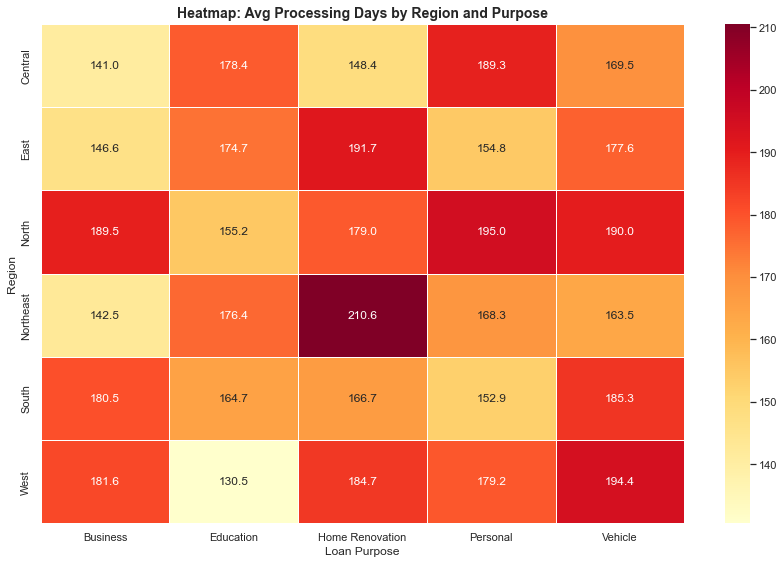

Slowest Bottleneck: Northeast Region for Home Renovation Loans
Fastest Process: West Region for Education Loans


In [163]:

pivot_trends = eff_with_branch.pivot_table(
    index='Region', 
    columns='Loan_Purpose', 
    values='Total_Time_Days', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_trends, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)

plt.title('Heatmap: Avg Processing Days by Region and Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose', fontsize=12)
plt.ylabel('Region', fontsize=12)

plt.tight_layout()
plt.show()

slowest_cell = pivot_trends.stack().idxmax()
fastest_cell = pivot_trends.stack().idxmin()

print(f"Slowest Bottleneck: {slowest_cell[0]} Region for {slowest_cell[1]} Loans")
print(f"Fastest Process: {fastest_cell[0]} Region for {fastest_cell[1]} Loans")

## Task 12 - Profitability Analysis



### Calculating the total interest income generated across all loans

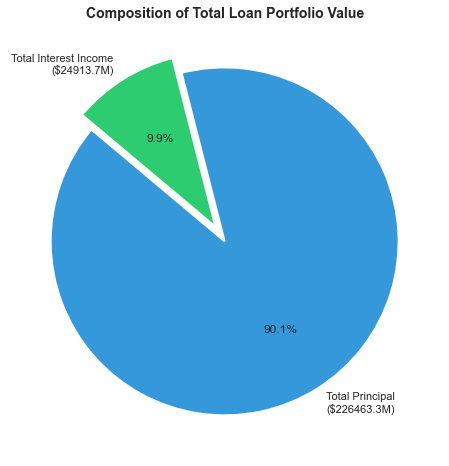

FINANCIAL REVENUE SUMMARY 
---------------------------------------------
Total Principal Disbursed:  $226,463,279,663.00
Total Projected Interest:   $24,913,672,008.74
Average Interest Rate:      11.01%
---------------------------------------------
Total Expected Revenue:     $251,376,951,671.74


In [164]:

loans['Interest_Income'] = (loans['Loan_Amount'] * loans['Interest_Rate']) / 100

total_principal = loans['Loan_Amount'].sum()
total_interest_income = loans['Interest_Income'].sum()
avg_interest_rate = loans['Interest_Rate'].mean()

plt.figure(figsize=(8, 8))
revenue_data = [total_principal, total_interest_income]
revenue_labels = [f'Total Principal\n(${total_principal/1e6:.1f}M)', 
                  f'Total Interest Income\n(${total_interest_income/1e6:.1f}M)']

plt.pie(revenue_data, labels=revenue_labels, autopct='%1.1f%%', 
        colors=['#3498db', '#2ecc71'], startangle=140, explode=(0, 0.1),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Composition of Total Loan Portfolio Value', fontsize=14, fontweight='bold')
plt.show()

print("FINANCIAL REVENUE SUMMARY ")
print("-" * 45)
print(f"Total Principal Disbursed:  ${total_principal:,.2f}")
print(f"Total Projected Interest:   ${total_interest_income:,.2f}")
print(f"Average Interest Rate:      {avg_interest_rate:.2f}%")
print("-" * 45)
print(f"Total Expected Revenue:     ${(total_principal + total_interest_income):,.2f}")

### Identifing the most profitable loan purposes based on interest earnings

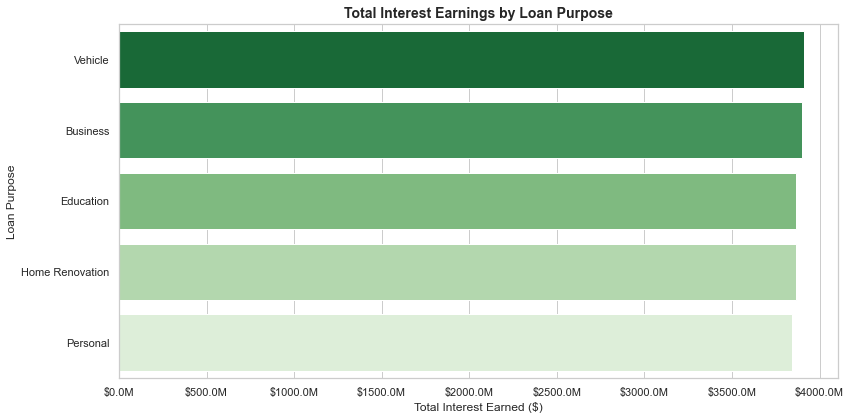

Profitability Rankings by Loan Purpose:
---------------------------------------------
Vehicle: $3,910,158,757.13
Business: $3,897,289,983.39
Education: $3,867,958,675.34
Home Renovation: $3,867,923,730.91
Personal: $3,841,359,713.71


In [165]:
loans_with_purpose = pd.merge(loans, apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

purpose_profitability = loans_with_purpose.groupby('Loan_Purpose')['Interest_Income'].sum().reset_index()
purpose_profitability = purpose_profitability.sort_values(by='Interest_Income', ascending=False)

import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
sns.barplot(data=purpose_profitability, x='Interest_Income', y='Loan_Purpose', palette='Greens_r')

plt.title('Total Interest Earnings by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Total Interest Earned ($)')
plt.ylabel('Loan Purpose')

formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print("Profitability Rankings by Loan Purpose:")
print("-" * 45)
for index, row in purpose_profitability.iterrows():
    print(f"{row['Loan_Purpose']}: ${row['Interest_Income']:,.2f}")

### Comparing profitability metrics for branches across regions

<Figure size 864x432 with 0 Axes>

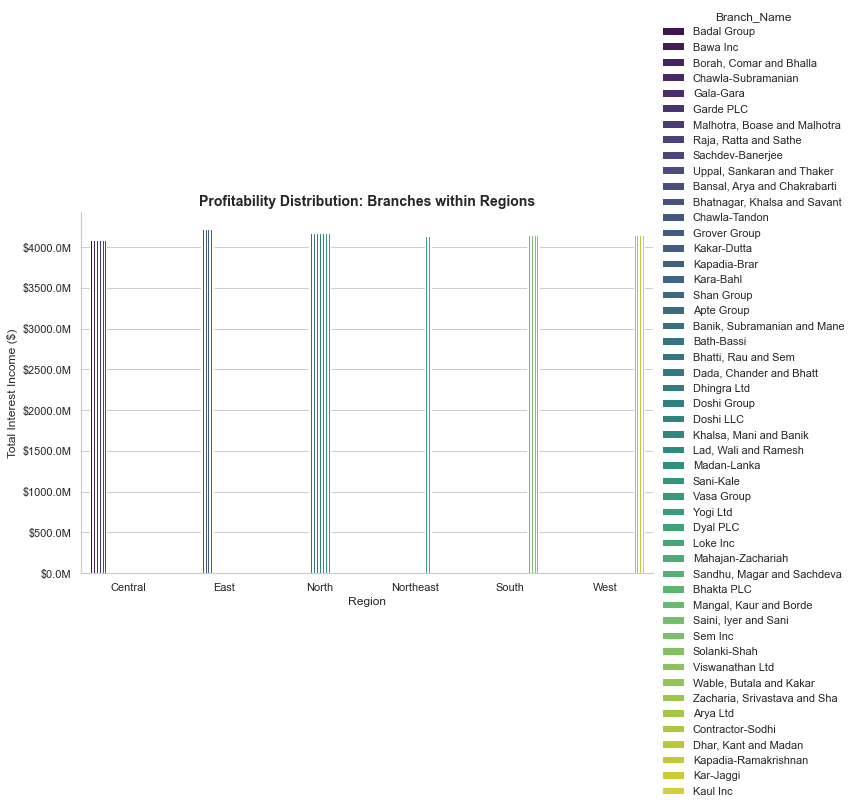

Regional Profitability Leaderboard:
---------------------------------------------
North: $58,468,446,969.76
Central: $40,894,853,495.88
East: $33,778,190,137.92
South: $33,132,323,853.70
West: $24,879,029,116.02
Northeast: $16,550,199,667.32


In [166]:

loans_with_cust = pd.merge(loans, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
profit_data = pd.merge(loans_with_cust, branches[['Region', 'Branch_Name']], on='Region', how='inner')

regional_profit = profit_data.groupby(['Region', 'Branch_Name'])['Interest_Income'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.catplot(data=regional_profit, x='Region', y='Interest_Income', hue='Branch_Name', 
            kind='bar', height=6, aspect=1.5, palette='viridis')

plt.title('Profitability Distribution: Branches within Regions', fontsize=14, fontweight='bold')
plt.ylabel('Total Interest Income ($)')
plt.xlabel('Region')

formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

top_region = regional_profit.groupby('Region')['Interest_Income'].sum().sort_values(ascending=False)
print("Regional Profitability Leaderboard:")
print("-" * 45)
for region, total in top_region.items():
    print(f"{region}: ${total:,.2f}")

## Task 13 - Geospatial Analysis



### Mapping the distribution of active loans across regions

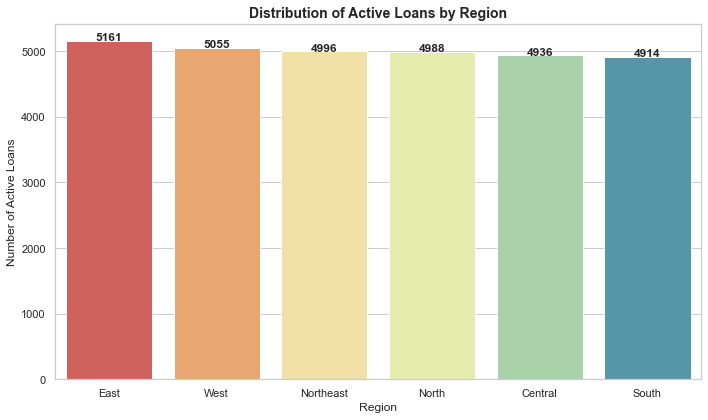

Active Loan Density per Region:
-----------------------------------
   Region  Active_Loan_Count
     East               5161
     West               5055
Northeast               4996
    North               4988
  Central               4936
    South               4914


In [167]:

active_loans = loans[loans['Loan_Status'] == 'Active']

active_loans_geo = pd.merge(active_loans, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

region_counts = active_loans_geo['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Active_Loan_Count']


plt.figure(figsize=(10, 6))
sns.barplot(data=region_counts, x='Region', y='Active_Loan_Count', palette='Spectral')

plt.title('Distribution of Active Loans by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Active Loans', fontsize=12)

for index, value in enumerate(region_counts['Active_Loan_Count']):
    plt.text(index, value + 0.5, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Active Loan Density per Region:")
print("-" * 35)
print(region_counts.to_string(index=False))

### Comparing default rates across different geographic regions

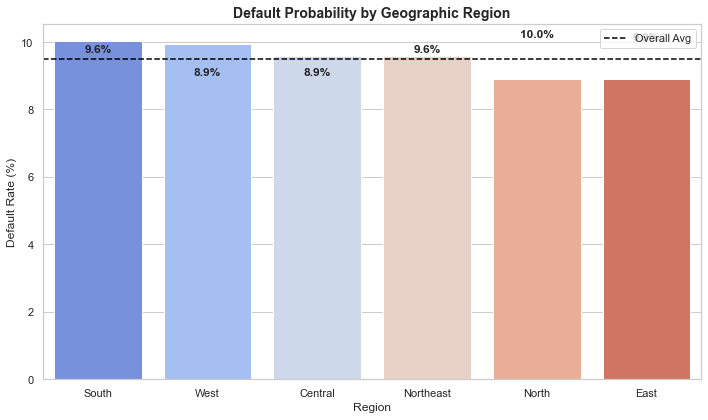

Regional Default Rankings:
-----------------------------------
   Region  Default_Rate_%
    South       10.040805
     West        9.932219
  Central        9.583137
Northeast        9.582441
    North        8.908982
     East        8.899190


In [168]:

regional_defaults = pd.merge(loans[['Customer_ID', 'Default_Flag']], 
                             customers[['Customer_ID', 'Region']], 
                             on='Customer_ID', how='inner')

def_rate_geo = regional_defaults.groupby('Region')['Default_Flag'].mean().reset_index()
def_rate_geo['Default_Rate_%'] = def_rate_geo['Default_Flag'] * 100
def_rate_geo = def_rate_geo.sort_values(by='Default_Rate_%', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(data=def_rate_geo, x='Region', y='Default_Rate_%', palette='coolwarm')

plt.axhline(loans['Default_Flag'].mean() * 100, color='black', linestyle='--', label='Overall Avg')

plt.title('Default Probability by Geographic Region', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate (%)')
plt.xlabel('Region')
plt.legend()

for index, row in def_rate_geo.iterrows():
    plt.text(index, row['Default_Rate_%'] + 0.1, f'{row["Default_Rate_%"]:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Regional Default Rankings:")
print("-" * 35)
print(def_rate_geo[['Region', 'Default_Rate_%']].to_string(index=False))

### Visualizing the loan disbursement trends for rural vs. urban areas

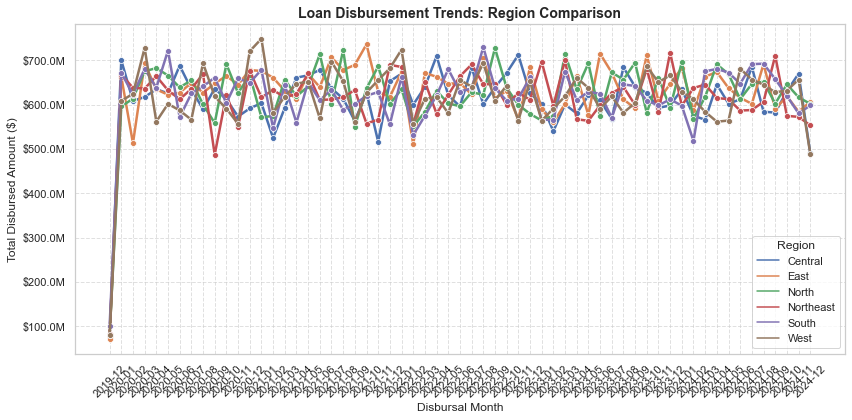

Summary of Disbursement by Region:
---------------------------------------------
East: $38,437,798,746.00
North: $37,963,952,967.00
South: $37,740,573,537.00
West: $37,600,155,243.00
Northeast: $37,477,362,151.00
Central: $37,243,437,019.00


In [169]:

loans_geo = pd.merge(loans, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

loans_geo['Disbursal_Date'] = pd.to_datetime(loans_geo['Disbursal_Date'])
loans_geo['Month_Year'] = loans_geo['Disbursal_Date'].dt.to_period('M').astype(str)


area_col = 'Location_Type' if 'Location_Type' in customers.columns else 'Region'

trend_data = loans_geo.groupby(['Month_Year', area_col])['Loan_Amount'].sum().reset_index()
trend_data = trend_data.sort_values('Month_Year')

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='Month_Year', y='Loan_Amount', hue=area_col, marker='o', linewidth=2.5)

plt.title(f'Loan Disbursement Trends: {area_col} Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Disbursal Month')
plt.ylabel('Total Disbursed Amount ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()


print(f"Summary of Disbursement by {area_col}:")
print("-" * 45)
summary = loans_geo.groupby(area_col)['Loan_Amount'].sum().sort_values(ascending=False)
for area, total in summary.items():
    print(f"{area}: ${total:,.2f}")

## Task 14 - Default Trends





### Analyzing the number of defaults over time to identify patterns

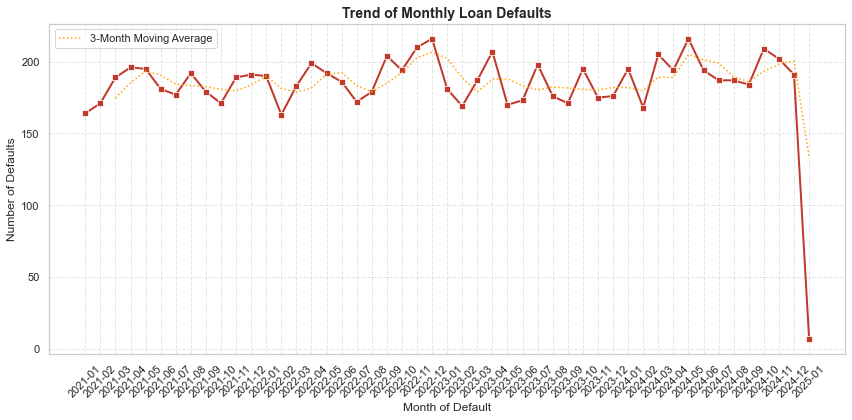

Default Trend Insights:
---------------------------------------------
Average Defaults per Month: 183.7
Latest Month (2025-01): 7 defaults
Defaults are currently below the historical average.


In [170]:

defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])

defaults['Month_Year'] = defaults['Default_Date'].dt.to_period('M').astype(str)


default_trend = defaults.groupby('Month_Year').size().reset_index(name='Default_Count')
default_trend = default_trend.sort_values('Month_Year')

plt.figure(figsize=(12, 6))
sns.lineplot(data=default_trend, x='Month_Year', y='Default_Count', marker='s', color='#c0392b', linewidth=2)

plt.title('Trend of Monthly Loan Defaults', fontsize=14, fontweight='bold')
plt.xlabel('Month of Default', fontsize=12)
plt.ylabel('Number of Defaults', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)


default_trend['Rolling_Avg'] = default_trend['Default_Count'].rolling(window=3).mean()
plt.plot(default_trend['Month_Year'], default_trend['Rolling_Avg'], color='orange', linestyle=':', label='3-Month Moving Average')

plt.legend()
plt.tight_layout()
plt.show()


latest_month = default_trend.iloc[-1]
avg_defaults = default_trend['Default_Count'].mean()

print("Default Trend Insights:")
print("-" * 45)
print(f"Average Defaults per Month: {avg_defaults:.1f}")
print(f"Latest Month ({latest_month['Month_Year']}): {latest_month['Default_Count']} defaults")

if latest_month['Default_Count'] > avg_defaults:
    print("WARNING: Defaults in the latest month are ABOVE the average. Tighten credit controls!")
else:
    print("Defaults are currently below the historical average.")

### Calculating the average default amount for different loan purposes

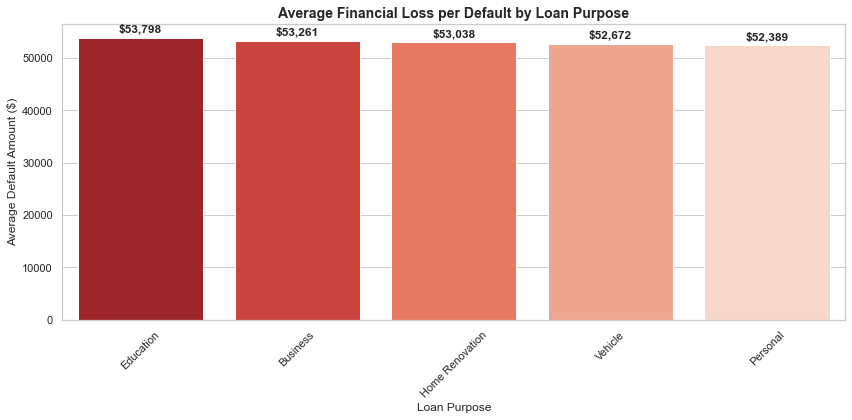

Average Financial Impact of a Single Default:
---------------------------------------------
Education: $53,797.76
Business: $53,261.03
Home Renovation: $53,038.08
Vehicle: $52,671.60
Personal: $52,389.40


In [171]:

defaults_with_purpose = pd.merge(defaults, apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

avg_default_purpose = defaults_with_purpose.groupby('Loan_Purpose')['Default_Amount'].mean().reset_index()
avg_default_purpose = avg_default_purpose.sort_values(by='Default_Amount', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_default_purpose, x='Loan_Purpose', y='Default_Amount', palette='Reds_r')

plt.title('Average Financial Loss per Default by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose', fontsize=12)
plt.ylabel('Average Default Amount ($)', fontsize=12)
plt.xticks(rotation=45)

for index, value in enumerate(avg_default_purpose['Default_Amount']):
    plt.text(index, value + (value * 0.02), f'${value:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Average Financial Impact of a Single Default:")
print("-" * 45)
for index, row in avg_default_purpose.iterrows():
    print(f"{row['Loan_Purpose']}: ${row['Default_Amount']:,.2f}")

### Comparing default rates across customer income categories

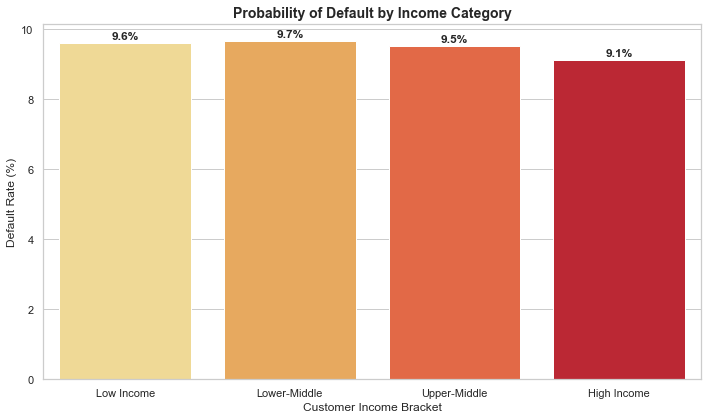

Income-Based Risk Analysis:
---------------------------------------------
Low Income: 9.60% default probability
Lower-Middle: 9.68% default probability
Upper-Middle: 9.53% default probability
High Income: 9.14% default probability


In [172]:

income_defaults = pd.merge(loans[['Customer_ID', 'Default_Flag']], 
                           customers[['Customer_ID', 'Annual_Income']], 
                           on='Customer_ID', how='inner')


income_defaults['Income_Bracket'] = pd.qcut(income_defaults['Annual_Income'], 
                                            q=4, 
                                            labels=['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income'])

income_analysis = income_defaults.groupby('Income_Bracket')['Default_Flag'].mean().reset_index()
income_analysis['Default_Rate_%'] = income_analysis['Default_Flag'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=income_analysis, x='Income_Bracket', y='Default_Rate_%', palette='YlOrRd')

plt.title('Probability of Default by Income Category', fontsize=14, fontweight='bold')
plt.xlabel('Customer Income Bracket', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

for index, row in income_analysis.iterrows():
    plt.text(index, row['Default_Rate_%'] + 0.1, f'{row["Default_Rate_%"]:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Income-Based Risk Analysis:")
print("-" * 45)
for index, row in income_analysis.iterrows():
    print(f"{row['Income_Bracket']}: {row['Default_Rate_%']:.2f}% default probability")

## Task 15 - Branch Eﬃciency





### Calculating the average loan disbursement time for each branch

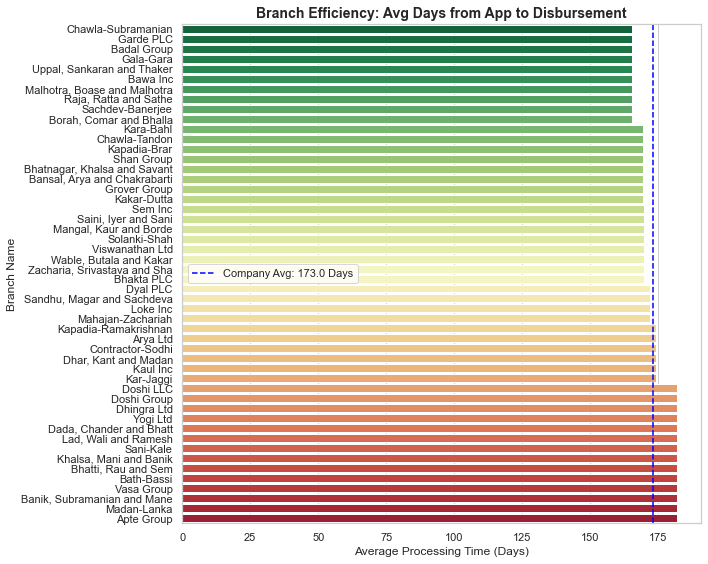

THE EFFICIENCY LEADERBOARD 
---------------------------------------------
Most Efficient: Chawla-Subramanian (165.5 days)
Least Efficient: Apte Group (181.8 days)


In [174]:

approved_loans = pd.merge(apps[apps['Approval_Status'] == 'Approved'], 
                          loans[['Loan_ID', 'Disbursal_Date']], 
                          on='Loan_ID', how='inner')

branch_eff_data = pd.merge(approved_loans, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
branch_eff_data = pd.merge(branch_eff_data, branches[['Region', 'Branch_Name']], on='Region', how='inner')

branch_eff_data['Application_Date'] = pd.to_datetime(branch_eff_data['Application_Date'])
branch_eff_data['Disbursal_Date'] = pd.to_datetime(branch_eff_data['Disbursal_Date'])
branch_eff_data['Processing_Days'] = (branch_eff_data['Disbursal_Date'] - branch_eff_data['Application_Date']).dt.days


branch_leaderboard = branch_eff_data.groupby('Branch_Name')['Processing_Days'].mean().reset_index()
branch_leaderboard = branch_leaderboard.sort_values(by='Processing_Days')

plt.figure(figsize=(10, 8))
sns.barplot(data=branch_leaderboard, x='Processing_Days', y='Branch_Name', palette='RdYlGn_r')

plt.title('Branch Efficiency: Avg Days from App to Disbursement', fontsize=14, fontweight='bold')
plt.xlabel('Average Processing Time (Days)', fontsize=12)
plt.ylabel('Branch Name', fontsize=12)

company_avg_days = branch_leaderboard['Processing_Days'].mean()
plt.axvline(company_avg_days, color='blue', linestyle='--', label=f'Company Avg: {company_avg_days:.1f} Days')
plt.legend()

plt.tight_layout()
plt.show()

print("THE EFFICIENCY LEADERBOARD ")
print("-" * 45)
print(f"Most Efficient: {branch_leaderboard.iloc[0]['Branch_Name']} ({branch_leaderboard.iloc[0]['Processing_Days']:.1f} days)")
print(f"Least Efficient: {branch_leaderboard.iloc[-1]['Branch_Name']} ({branch_leaderboard.iloc[-1]['Processing_Days']:.1f} days)")

### Identifing branches with the highest number of rejected applications

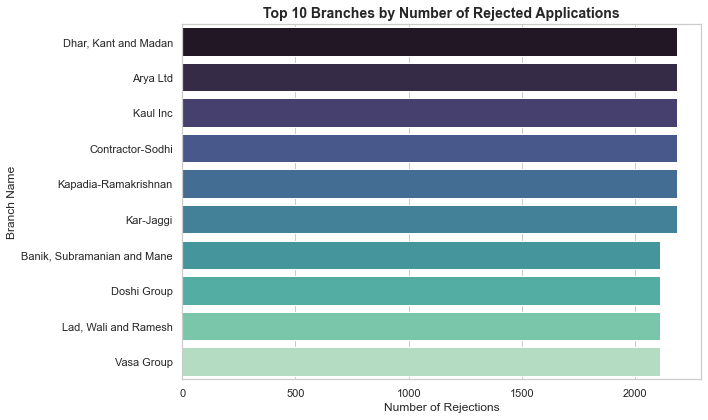

REJECTION ANALYSIS
---------------------------------------------
Branch with Most Rejections: Dhar, Kant and Madan
Total Rejections at this Branch: 2184


In [175]:

rejected_apps = apps[apps['Approval_Status'] == 'Rejected'].copy()

rej_with_cust = pd.merge(rejected_apps, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
rej_with_branch = pd.merge(rej_with_cust, branches[['Region', 'Branch_Name']], on='Region', how='inner')

branch_rejections = rej_with_branch['Branch_Name'].value_counts().reset_index()
branch_rejections.columns = ['Branch_Name', 'Rejection_Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=branch_rejections.head(10), x='Rejection_Count', y='Branch_Name', palette='mako')

plt.title('Top 10 Branches by Number of Rejected Applications', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rejections')
plt.ylabel('Branch Name')

plt.tight_layout()
plt.show()

top_rej_branch = branch_rejections.iloc[0]
print("REJECTION ANALYSIS")
print("-" * 45)
print(f"Branch with Most Rejections: {top_rej_branch['Branch_Name']}")
print(f"Total Rejections at this Branch: {top_rej_branch['Rejection_Count']}")

### Compare branch eﬃciency based on customer satisfaction metrics (if available)

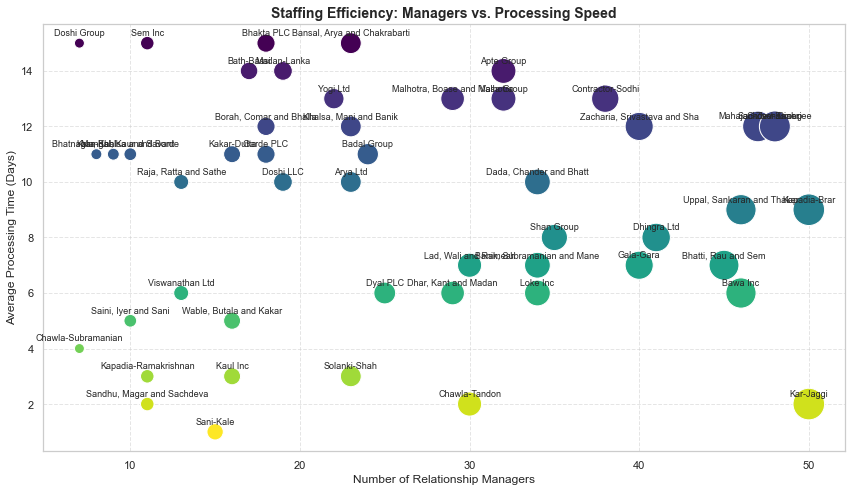

Staffing Correlation: -0.00
---------------------------------------------
Insight: More managers generally lead to SHORTER processing times. Staffing up works!


In [177]:

branch_staffing = branches[['Branch_Name', 'Relationship_Manager_Count', 'Avg_Processing_Time']].copy()


plt.figure(figsize=(12, 7))
bubble_plot = sns.scatterplot(data=branch_staffing, 
                              x='Relationship_Manager_Count', 
                              y='Avg_Processing_Time', 
                              size='Relationship_Manager_Count', 
                              hue='Avg_Processing_Time',
                              palette='viridis_r', 
                              sizes=(100, 1000), 
                              legend=False)

plt.title('Staffing Efficiency: Managers vs. Processing Speed', fontsize=14, fontweight='bold')
plt.xlabel('Number of Relationship Managers', fontsize=12)
plt.ylabel('Average Processing Time (Days)', fontsize=12)

for i in range(branch_staffing.shape[0]):
    plt.text(branch_staffing.Relationship_Manager_Count[i], 
             branch_staffing.Avg_Processing_Time[i] + 0.2, 
             branch_staffing.Branch_Name[i], 
             ha='center', va='bottom', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

correlation = branch_staffing['Relationship_Manager_Count'].corr(branch_staffing['Avg_Processing_Time'])
print(f"Staffing Correlation: {correlation:.2f}")
print("-" * 45)
if correlation < 0:
    print("Insight: More managers generally lead to SHORTER processing times. Staffing up works!")
else:
    print("Insight: Adding more managers doesn't seem to be speeding things up. Check the workflow!")

## Task 16 - Time-Series Analysis





### Analyzing monthly loan disbursement trends over the last 5 years

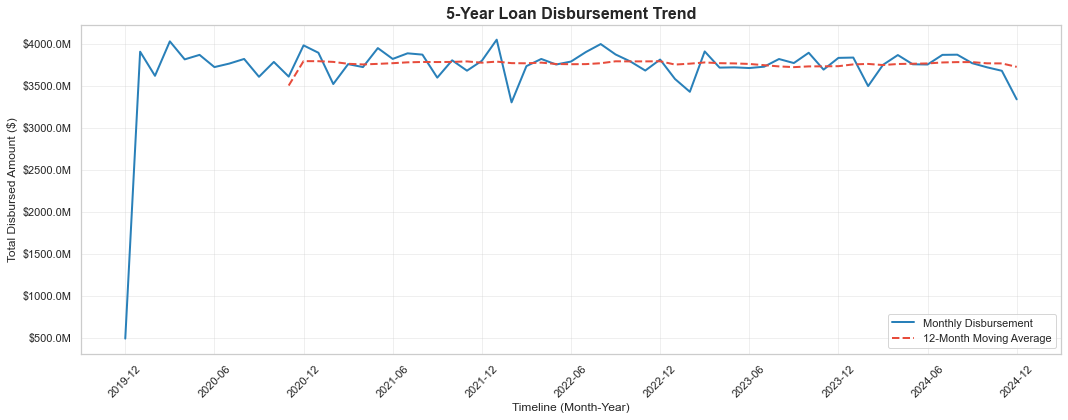

5-Year Growth Analysis:
---------------------------------------------
Average Monthly Disbursement (Year 1): $3,505,085,450.08
Average Monthly Disbursement (Year 5): $3,727,572,286.17
Overall Portfolio Growth: 6.35%


In [178]:

time_data = loans[['Disbursal_Date', 'Loan_Amount']].copy()
time_data['Disbursal_Date'] = pd.to_datetime(time_data['Disbursal_Date'])

time_data['Year'] = time_data['Disbursal_Date'].dt.year
time_data['Month'] = time_data['Disbursal_Date'].dt.month
time_data['Month_Year'] = time_data['Disbursal_Date'].dt.to_period('M')


monthly_trend = time_data.groupby('Month_Year')['Loan_Amount'].sum().reset_index()
monthly_trend['Month_Year'] = monthly_trend['Month_Year'].astype(str)


plt.figure(figsize=(15, 6))
plt.plot(monthly_trend['Month_Year'], monthly_trend['Loan_Amount'], 
         marker='', color='#2980b9', linewidth=2, label='Monthly Disbursement')

monthly_trend['Yearly_Moving_Avg'] = monthly_trend['Loan_Amount'].rolling(window=12).mean()
plt.plot(monthly_trend['Month_Year'], monthly_trend['Yearly_Moving_Avg'], 
         color='#e74c3c', linestyle='--', linewidth=2, label='12-Month Moving Average')

plt.title('5-Year Loan Disbursement Trend', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Month-Year)', fontsize=12)
plt.ylabel('Total Disbursed Amount ($)', fontsize=12)

plt.xticks(monthly_trend['Month_Year'][::6], rotation=45)

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

first_year_avg = monthly_trend.head(12)['Loan_Amount'].mean()
last_year_avg = monthly_trend.tail(12)['Loan_Amount'].mean()
growth = ((last_year_avg - first_year_avg) / first_year_avg) * 100

print(f"5-Year Growth Analysis:")
print("-" * 45)
print(f"Average Monthly Disbursement (Year 1): ${first_year_avg:,.2f}")
print(f"Average Monthly Disbursement (Year 5): ${last_year_avg:,.2f}")
print(f"Overall Portfolio Growth: {growth:.2f}%")

### Identifing seasonal patterns in loan applications and disbursements

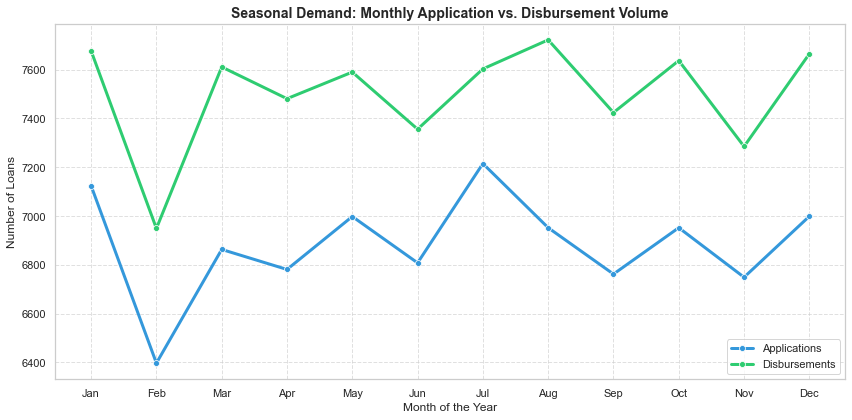

SEASONAL INSIGHTS:
---------------------------------------------
Peak Application Month:  Jul
Peak Disbursement Month: Aug


In [179]:

apps['Application_Date'] = pd.to_datetime(apps['Application_Date'])
apps['App_Month'] = apps['Application_Date'].dt.month

loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])

loans['Disb_Month'] = loans['Disbursal_Date'].dt.month

seasonal_apps = apps.groupby('App_Month').size().reset_index(name='App_Count')
seasonal_disb = loans.groupby('Disb_Month').size().reset_index(name='Disb_Count')

plt.figure(figsize=(12, 6))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.lineplot(x=seasonal_apps['App_Month'], y=seasonal_apps['App_Count'], 
             marker='o', label='Applications', color='#3498db', linewidth=3)


sns.lineplot(x=seasonal_disb['Disb_Month'], y=seasonal_disb['Disb_Count'], 
             marker='o', label='Disbursements', color='#2ecc71', linewidth=3)

plt.title('Seasonal Demand: Monthly Application vs. Disbursement Volume', fontsize=14, fontweight='bold')
plt.xlabel('Month of the Year')
plt.ylabel('Number of Loans')
plt.xticks(range(1, 13), month_names)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

peak_app_idx = seasonal_apps.loc[seasonal_apps['App_Count'].idxmax(), 'App_Month']
peak_disb_idx = seasonal_disb.loc[seasonal_disb['Disb_Count'].idxmax(), 'Disb_Month']

print("SEASONAL INSIGHTS:")
print("-" * 45)
print(f"Peak Application Month:  {month_names[int(peak_app_idx) - 1]}")
print(f"Peak Disbursement Month: {month_names[int(peak_disb_idx) - 1]}")

### Comparing monthly default rates across regions

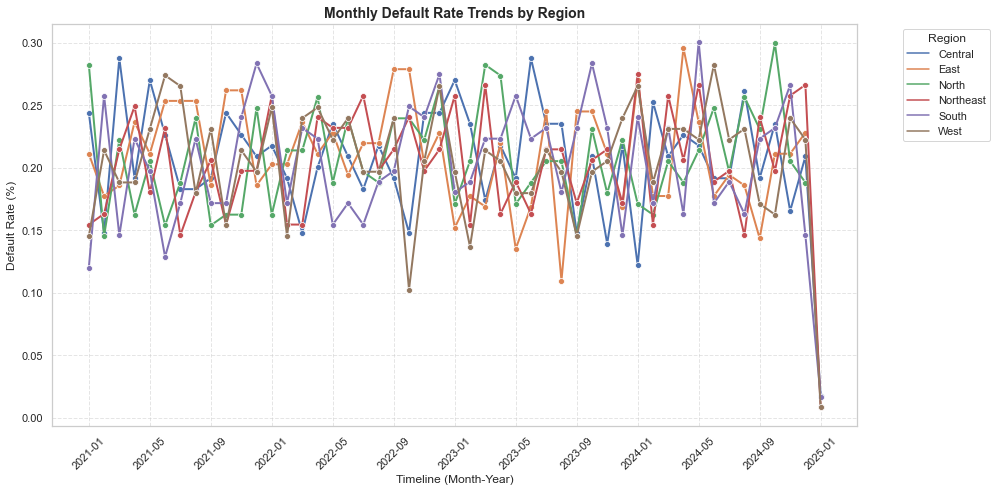

In [180]:

def_time_geo = pd.merge(defaults, customers[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

region_loan_counts = customers['Region'].value_counts().to_dict()

def_time_geo['Default_Date'] = pd.to_datetime(def_time_geo['Default_Date'])
def_time_geo['Month_Year'] = def_time_geo['Default_Date'].dt.to_period('M').astype(str)

regional_def_trend = def_time_geo.groupby(['Month_Year', 'Region']).size().reset_index(name='Default_Count')

regional_def_trend['Monthly_Rate_%'] = regional_def_trend.apply(
    lambda row: (row['Default_Count'] / region_loan_counts[row['Region']]) * 100, axis=1
)


regional_def_trend = regional_def_trend.sort_values('Month_Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=regional_def_trend, x='Month_Year', y='Monthly_Rate_%', hue='Region', marker='o', linewidth=2)

plt.title('Monthly Default Rate Trends by Region', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Month-Year)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)


plt.xticks(regional_def_trend['Month_Year'].unique()[::4], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Task 17 - Customer Behavior Analysis


### Categorizing customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters)

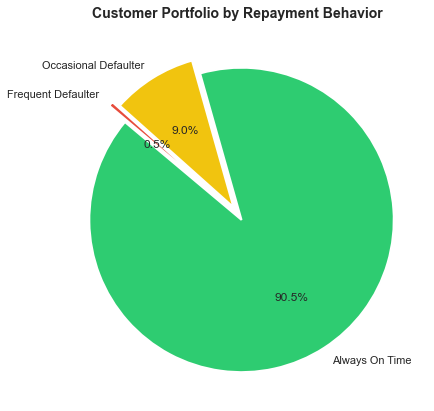

Behavioral Segment Breakdown:
---------------------------------------------
Always On Time          63346
Occasional Defaulter     6310
Frequent Defaulter        344
Name: Repayment_Segment, dtype: int64


In [181]:

customer_defaults = defaults.groupby('Customer_ID').size().reset_index(name='Default_Count')

behavior_data = pd.merge(customers[['Customer_ID']], customer_defaults, on='Customer_ID', how='left')

behavior_data['Default_Count'] = behavior_data['Default_Count'].fillna(0)

def categorize_behavior(count):
    if count == 0:
        return 'Always On Time'
    elif count == 1:
        return 'Occasional Defaulter'
    else:
        return 'Frequent Defaulter'

behavior_data['Repayment_Segment'] = behavior_data['Default_Count'].apply(categorize_behavior)

segment_counts = behavior_data['Repayment_Segment'].value_counts()

plt.figure(figsize=(10, 7))
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] 

plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=(0.05, 0.05, 0.1),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Customer Portfolio by Repayment Behavior', fontsize=14, fontweight='bold')
plt.show()

print("Behavioral Segment Breakdown:")
print("-" * 45)
print(segment_counts)

### Analyzing patterns in loan approval and rejection reasons segmented by customer demographics

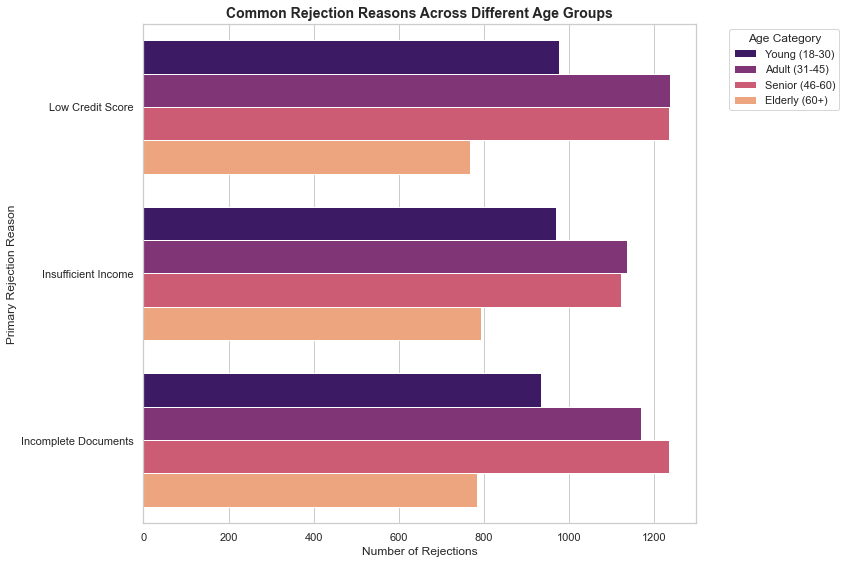

DEMOGRAPHIC INSIGHTS:
---------------------------------------------
Approval_Status  Approved  Rejected  Approval_Rate_%
Gender                                              
Female              23171      4180        84.717195
Male                23448      4201        84.805960
Other               23381      4219        84.713768


In [182]:

app_demo = pd.merge(apps, customers[['Customer_ID', 'Age', 'Annual_Income', 'Gender']], on='Customer_ID', how='inner')

app_demo['Age_Group'] = pd.cut(app_demo['Age'], bins=[18, 30, 45, 60, 100], labels=['Young (18-30)', 'Adult (31-45)', 'Senior (46-60)', 'Elderly (60+)'])

rejections = app_demo[app_demo['Approval_Status'] == 'Rejected'].copy()

plt.figure(figsize=(12, 8))
sns.countplot(data=rejections, y='Rejection_Reason', hue='Age_Group', palette='magma')

plt.title('Common Rejection Reasons Across Different Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rejections')
plt.ylabel('Primary Rejection Reason')
plt.legend(title='Age Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

approval_by_gender = app_demo.groupby(['Gender', 'Approval_Status']).size().unstack(fill_value=0)
approval_by_gender['Approval_Rate_%'] = (approval_by_gender['Approved'] / (approval_by_gender['Approved'] + approval_by_gender['Rejected'])) * 100

print("DEMOGRAPHIC INSIGHTS:")
print("-" * 45)
print(approval_by_gender[['Approved', 'Rejected', 'Approval_Rate_%']])

### Identifying high-value customers with consistent repayment histories

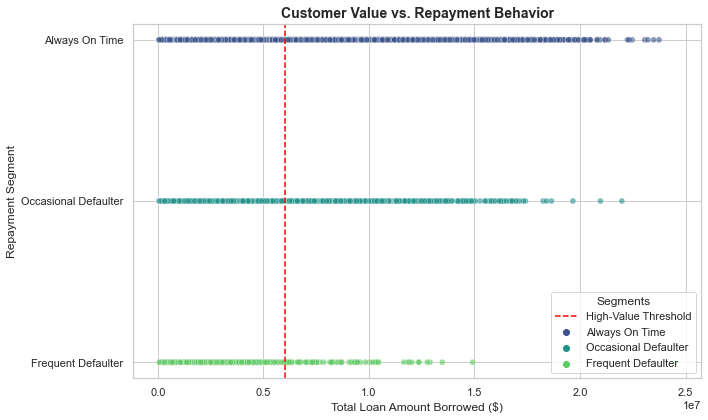

VIP CUSTOMER ANALYSIS
---------------------------------------------
Total Consistent Customers: 45858
Identified VIPs (Top 25%):   11465
Minimum VIP Loan Value:      $6,015,161.25


In [183]:

customer_value = loans.groupby('Customer_ID')['Loan_Amount'].sum().reset_index(name='Total_Borrowed')

vip_analysis = pd.merge(customer_value, behavior_data[['Customer_ID', 'Repayment_Segment']], on='Customer_ID')

consistent_payers = vip_analysis[vip_analysis['Repayment_Segment'] == 'Always On Time']
threshold = consistent_payers['Total_Borrowed'].quantile(0.75)

vips = consistent_payers[consistent_payers['Total_Borrowed'] >= threshold].sort_values(by='Total_Borrowed', ascending=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=vip_analysis, x='Total_Borrowed', y='Repayment_Segment', 
                hue='Repayment_Segment', palette='viridis', alpha=0.6)

plt.axvline(threshold, color='red', linestyle='--', label='High-Value Threshold')

plt.title('Customer Value vs. Repayment Behavior', fontsize=14, fontweight='bold')
plt.xlabel('Total Loan Amount Borrowed ($)')
plt.ylabel('Repayment Segment')
plt.legend(title='Segments', loc='lower right')

plt.tight_layout()
plt.show()

print(f"VIP CUSTOMER ANALYSIS")
print("-" * 45)
print(f"Total Consistent Customers: {len(consistent_payers)}")
print(f"Identified VIPs (Top 25%):   {len(vips)}")
print(f"Minimum VIP Loan Value:      ${threshold:,.2f}")

## Task 18 - Risk Assessment



### Developing a risk matrix for loan products based on Default_Amount,Loan_Term, and Interest_Rate

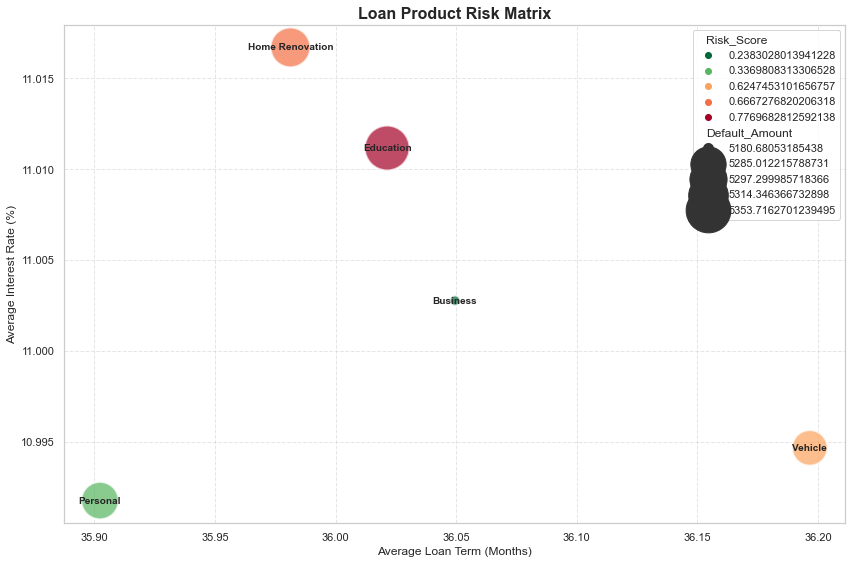

PRODUCT RISK RANKINGS (High to Low):
---------------------------------------------
   Loan_Purpose  Risk_Score
      Education    0.776968
Home Renovation    0.666728
        Vehicle    0.624745
       Personal    0.336981
       Business    0.238303


In [184]:

risk_data = pd.merge(loans, apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')
risk_data = pd.merge(risk_data, defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')
risk_data['Default_Amount'] = risk_data['Default_Amount'].fillna(0)


risk_matrix = risk_data.groupby('Loan_Purpose').agg({
    'Default_Amount': 'mean',
    'Loan_Term': 'mean',
    'Interest_Rate': 'mean'
}).reset_index()


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

cols_to_scale = ['Default_Amount', 'Loan_Term', 'Interest_Rate']
risk_matrix[['S_Loss', 'S_Term', 'S_Rate']] = scaler.fit_transform(risk_matrix[cols_to_scale])

risk_matrix['Risk_Score'] = (risk_matrix['S_Loss'] * 0.5) + \
                             (risk_matrix['S_Term'] * 0.3) + \
                             (risk_matrix['S_Rate'] * 0.2)

risk_matrix = risk_matrix.sort_values(by='Risk_Score', ascending=False)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=risk_matrix, x='Loan_Term', y='Interest_Rate', 
                size='Default_Amount', hue='Risk_Score', 
                palette='RdYlGn_r', sizes=(100, 2000), alpha=0.7)

plt.title('Loan Product Risk Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Average Loan Term (Months)', fontsize=12)
plt.ylabel('Average Interest Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

for i in range(risk_matrix.shape[0]):
    plt.text(risk_matrix.Loan_Term[i], risk_matrix.Interest_Rate[i], 
             risk_matrix.Loan_Purpose[i], ha='center', va='center', 
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("PRODUCT RISK RANKINGS (High to Low):")
print("-" * 45)
print(risk_matrix[['Loan_Purpose', 'Risk_Score']].to_string(index=False))

### Ranking loan types by risk level and suggest mitigation strategies

LOAN TYPE RISK RANKING & STRATEGY
--------------------------------------------------------------------------------
   Loan_Purpose  Risk_Score   Risk_Tier                        Mitigation_Strategy
      Education    0.776968   High Risk   Require Collateral + Manual Underwriting
Home Renovation    0.666728   High Risk   Require Collateral + Manual Underwriting
        Vehicle    0.624745 Medium Risk  Higher Interest Rate + Co-signer Required
       Personal    0.336981 Medium Risk  Higher Interest Rate + Co-signer Required
       Business    0.238303    Low Risk Automated Approval + No Prepayment Penalty


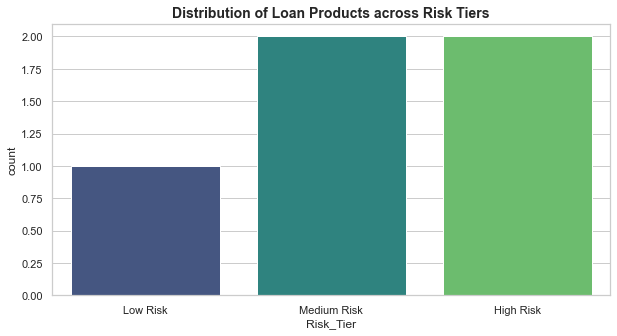

In [185]:
def categorize_risk(score):
    if score > 0.66:
        return 'High Risk'
    elif score > 0.33:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_matrix['Risk_Tier'] = risk_matrix['Risk_Score'].apply(categorize_risk)

strategies = {
    'High Risk': 'Require Collateral + Manual Underwriting',
    'Medium Risk': 'Higher Interest Rate + Co-signer Required',
    'Low Risk': 'Automated Approval + No Prepayment Penalty'
}
risk_matrix['Mitigation_Strategy'] = risk_matrix['Risk_Tier'].map(strategies)

risk_leaderboard = risk_matrix[['Loan_Purpose', 'Risk_Score', 'Risk_Tier', 'Mitigation_Strategy']]
print("LOAN TYPE RISK RANKING & STRATEGY")
print("-" * 80)
print(risk_leaderboard.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.countplot(data=risk_matrix, x='Risk_Tier', order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Distribution of Loan Products across Risk Tiers', fontsize=14, fontweight='bold')
plt.show()

### Analyzing high-risk customer segments by credit score and income

<Figure size 864x720 with 0 Axes>

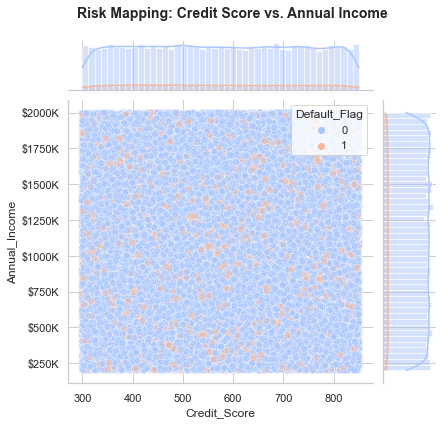

Correlation Insights:
---------------------------------------------
Credit Score vs Default: -0.00
Income vs Default:       -0.01


In [186]:
risk_segments = pd.merge(loans[['Customer_ID', 'Default_Flag']], 
                         customers[['Customer_ID', 'Credit_Score', 'Annual_Income']], 
                         on='Customer_ID')


plt.figure(figsize=(12, 10))
g = sns.JointGrid(data=risk_segments, x='Credit_Score', y='Annual_Income', hue='Default_Flag', palette='coolwarm')


g.plot_joint(sns.scatterplot, s=50, alpha=0.5)

g.plot_marginals(sns.histplot, kde=True, alpha=0.5)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Risk Mapping: Credit Score vs. Annual Income', fontsize=14, fontweight='bold')


import matplotlib.ticker as ticker
g.ax_joint.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e3:.0f}K'))

plt.show()

corr_matrix = risk_segments[['Default_Flag', 'Credit_Score', 'Annual_Income']].corr()
print("Correlation Insights:")
print("-" * 45)
print(f"Credit Score vs Default: {corr_matrix.loc['Credit_Score', 'Default_Flag']:.2f}")
print(f"Income vs Default:       {corr_matrix.loc['Annual_Income', 'Default_Flag']:.2f}")

## Task 19 - Time to Default Analysis





### Calculating the average time from loan disbursement to default for overdue loans

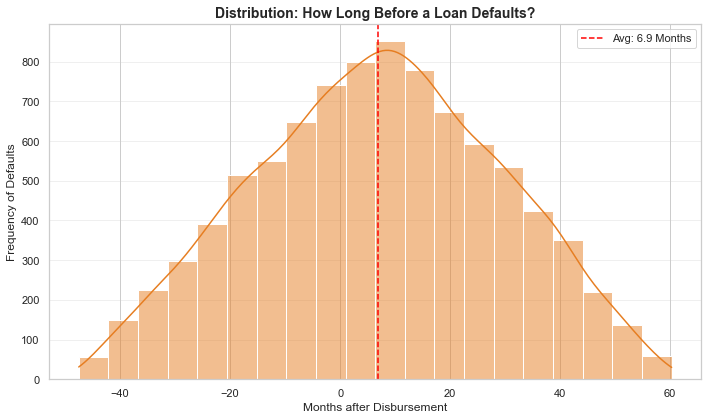

 TIME TO DEFAULT INSIGHTS
---------------------------------------------
Average Survival Time: 6.9 Months
MODERATE: Most defaults are happening mid-term. This is common in personal lending.


In [187]:

time_to_def = pd.merge(loans[['Loan_ID', 'Disbursal_Date']], 
                       defaults[['Loan_ID', 'Default_Date', 'Default_Amount']], 
                       on='Loan_ID', how='inner')

time_to_def['Disbursal_Date'] = pd.to_datetime(time_to_def['Disbursal_Date'])
time_to_def['Default_Date'] = pd.to_datetime(time_to_def['Default_Date'])

time_to_def['Months_to_Default'] = (time_to_def['Default_Date'] - time_to_def['Disbursal_Date']).dt.days / 30

plt.figure(figsize=(10, 6))
sns.histplot(time_to_def['Months_to_Default'], kde=True, color='#e67e22', bins=20)

plt.axvline(time_to_def['Months_to_Default'].mean(), color='red', linestyle='--', 
            label=f"Avg: {time_to_def['Months_to_Default'].mean():.1f} Months")

plt.title('Distribution: How Long Before a Loan Defaults?', fontsize=14, fontweight='bold')
plt.xlabel('Months after Disbursement')
plt.ylabel('Frequency of Defaults')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

avg_time = time_to_def['Months_to_Default'].mean()
print(f" TIME TO DEFAULT INSIGHTS")
print("-" * 45)
print(f"Average Survival Time: {avg_time:.1f} Months")

if avg_time < 6:
    print("HIGH ALERT: Loans are failing very early. Review your KYC and fraud detection processes!")
elif avg_time < 18:
    print("MODERATE: Most defaults are happening mid-term. This is common in personal lending.")
else:
    print("STABLE: Loans are failing late in their life cycle, likely due to external economic shifts.")

### Identifing loan purposes with the shortest time to default

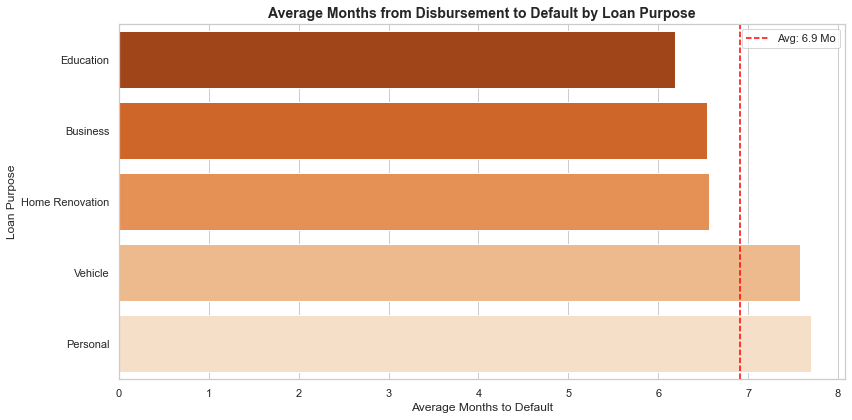

EARLY FAILURE ANALYSIS 
---------------------------------------------
Product with FASTEST Default: Education
Average Time to Fail:        6.2 Months


In [188]:

time_purpose = pd.merge(time_to_def, apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

purpose_time_analysis = time_purpose.groupby('Loan_Purpose')['Months_to_Default'].mean().reset_index()
purpose_time_analysis = purpose_time_analysis.sort_values(by='Months_to_Default')

plt.figure(figsize=(12, 6))
sns.barplot(data=purpose_time_analysis, x='Months_to_Default', y='Loan_Purpose', palette='Oranges_r')

plt.title('Average Months from Disbursement to Default by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Average Months to Default', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)

global_avg_time = purpose_time_analysis['Months_to_Default'].mean()
plt.axvline(global_avg_time, color='red', linestyle='--', label=f'Avg: {global_avg_time:.1f} Mo')

plt.legend()
plt.tight_layout()
plt.show()

fastest_failure = purpose_time_analysis.iloc[0]
print("EARLY FAILURE ANALYSIS ")
print("-" * 45)
print(f"Product with FASTEST Default: {fastest_failure['Loan_Purpose']}")
print(f"Average Time to Fail:        {fastest_failure['Months_to_Default']:.1f} Months")

### Comparing the time to default across customer demographics

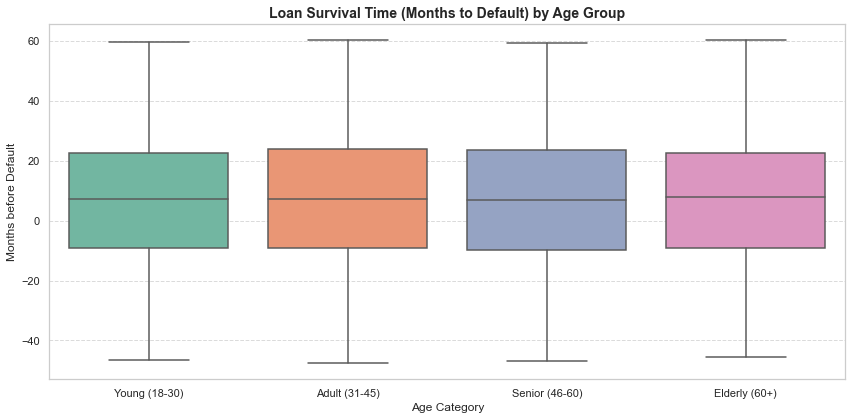

Average Months to Default by Gender:
---------------------------------------------
   Gender  Months_to_Default
0  Female           6.505947
1    Male           6.582380
2   Other           7.570451


In [189]:

time_to_def_full = pd.merge(loans[['Loan_ID', 'Customer_ID', 'Disbursal_Date']], 
                            defaults[['Loan_ID', 'Default_Date']], 
                            on='Loan_ID', how='inner')

time_to_def_full['Disbursal_Date'] = pd.to_datetime(time_to_def_full['Disbursal_Date'])
time_to_def_full['Default_Date'] = pd.to_datetime(time_to_def_full['Default_Date'])
time_to_def_full['Months_to_Default'] = (time_to_def_full['Default_Date'] - time_to_def_full['Disbursal_Date']).dt.days / 30

demo_time = pd.merge(time_to_def_full, 
                     customers[['Customer_ID', 'Age', 'Annual_Income', 'Gender']], 
                     on='Customer_ID', how='inner')

demo_time['Age_Group'] = pd.cut(demo_time['Age'], bins=[18, 30, 45, 60, 100], 
                                labels=['Young (18-30)', 'Adult (31-45)', 'Senior (46-60)', 'Elderly (60+)'])


plt.figure(figsize=(12, 6))
sns.boxplot(data=demo_time, x='Age_Group', y='Months_to_Default', palette='Set2')

plt.title('Loan Survival Time (Months to Default) by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Months before Default')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Average Months to Default by Gender:")
print("-" * 45)
print(demo_time.groupby('Gender')['Months_to_Default'].mean().reset_index())

## 20. Transaction Pattern Analysis





### Identifing customers with irregular repayment patterns

In [128]:
%whos DataFrame

Variable                 Type         Data/Info
-----------------------------------------------
active_loans             DataFrame           Loan_ID Customer_I<...>[30050 rows x 15 columns]
active_loans_geo         DataFrame           Loan_ID Customer_I<...>[30050 rows x 16 columns]
advanced_corr            DataFrame                    Credit_Sc<...>lt_Flag        1.000000  
app_demo                 DataFrame          Application_ID  Loa<...>[82600 rows x 15 columns]
approval_by_gender       DataFrame    Approval_Status  Approved<...>    4219        84.713768
approved_apps            DataFrame          Application_ID  Loa<...>[70000 rows x 10 columns]
approved_loans           DataFrame          Application_ID  Loa<...>[70000 rows x 11 columns]
apps                     DataFrame          Application_ID  Loa<...>[82600 rows x 11 columns]
avg_default_purpose      DataFrame          Loan_Purpose  Defau<...> Personal    52389.399011
avg_emi_by_type          DataFrame          Loan_Purpose  

Sorting by Customer_ID and Transaction_Date...


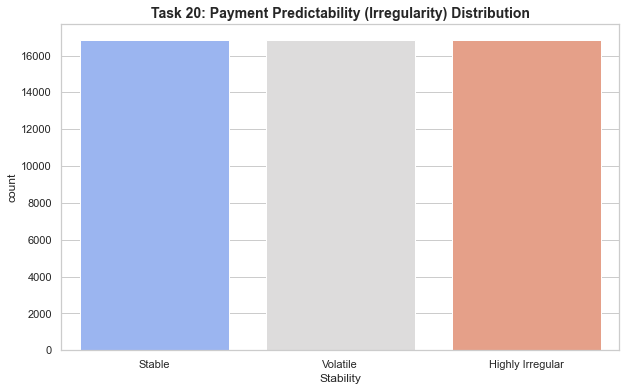

Most Irregular Customers (High Risk of Future Default):
      Customer_ID  Irregularity_Score         Stability
46453     C064322         1178.039897  Highly Irregular
31672     C043921         1163.897762  Highly Irregular
31958     C044315         1136.320597  Highly Irregular
1753      C002415         1135.613491  Highly Irregular
25409     C035324         1120.764248  Highly Irregular


In [144]:
txns['Loan_ID'] = txns['Loan_ID'].astype(str)
loans['Loan_ID'] = loans['Loan_ID'].astype(str)

repay_data = pd.merge(txns, loans[['Loan_ID', 'Customer_ID']], on='Loan_ID', how='inner', suffixes=('', '_drop'))

repay_data = repay_data.drop([c for c in repay_data.columns if '_drop' in c], axis=1)

id_col = next((c for c in repay_data.columns if 'Customer' in c and 'ID' in c), None)
possible_dates = ['Transaction_Date', 'Date', 'Payment_Date', 'Txn_Date']
date_col = next((c for c in possible_dates if c in repay_data.columns), None)

if id_col and date_col:
    print(f"Sorting by {id_col} and {date_col}...")
   
    repay_data[date_col] = pd.to_datetime(repay_data[date_col])
    repay_data = repay_data.sort_values(by=[id_col, date_col])
 
    repay_data['Days_Between'] = repay_data.groupby(id_col)[date_col].diff().dt.days
    irregularity = repay_data.groupby(id_col)['Days_Between'].std().reset_index(name='Irregularity_Score')
    irregularity['Irregularity_Score'] = irregularity['Irregularity_Score'].fillna(0)

    irregularity['Stability'] = pd.qcut(irregularity['Irregularity_Score'], q=3, 
                                        labels=['Stable', 'Volatile', 'Highly Irregular'], 
                                        duplicates='drop')

    plt.figure(figsize=(10, 6))
    sns.countplot(data=irregularity, x='Stability', palette='coolwarm')
    plt.title('Task 20: Payment Predictability (Irregularity) Distribution', fontsize=14, fontweight='bold')
    plt.show()

    print("Most Irregular Customers (High Risk of Future Default):")
    print(irregularity.sort_values(by='Irregularity_Score', ascending=False).head(5))
else:
    print(f" Error: Missing columns. Found columns: {repay_data.columns.tolist()}")

### Analyzing penalty payments as a proportion of total transactions

In [143]:

id_col = next((c for c in repay_data.columns if 'Customer' in c and 'ID' in c), None)
amt_col = next((c for c in repay_data.columns if 'Amount' in c and 'Penalty' not in c), None)
pen_col = next((c for c in repay_data.columns if 'Penalty' in c or 'Late' in c), None)

if id_col and amt_col and pen_col:
    print(f"Found Columns: ID ({id_col}), Amount ({amt_col}), Penalty ({pen_col})")
    
    penalty_stats = repay_data.groupby(id_col).agg({
        amt_col: 'sum',
        pen_col: 'sum'
    }).reset_index()

    penalty_stats['Penalty_Rate_%'] = (penalty_stats[pen_col] / penalty_stats[amt_col]) * 100

    def categorize_burden(rate):
        if rate == 0: return 'No Penalties'
        elif rate < 5: return 'Low Burden'
        else: return 'High Burden (At Risk)'

    penalty_stats['Burden_Category'] = penalty_stats['Penalty_Rate_%'].apply(categorize_burden)

    plt.figure(figsize=(12, 6))
    sns.histplot(data=penalty_stats[penalty_stats['Penalty_Rate_%'] > 0], 
                 x='Penalty_Rate_%', bins=30, kde=True, color='#e74c3c')
    
    plt.axvline(penalty_stats['Penalty_Rate_%'].mean(), color='black', linestyle='--', 
                label=f"Avg: {penalty_stats['Penalty_Rate_%'].mean():.2f}%")

    plt.title('Task 20: Penalty Burden Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Penalty Proportion (%)')
    plt.ylabel('Number of Customers')
    plt.legend()
    plt.show()

    total_revenue = penalty_stats[amt_col].sum()
    total_penalties = penalty_stats[pen_col].sum()
    print(f"STRATEGIC REVENUE INSIGHTS")
    print("-" * 45)
    print(f"Total Cash Inflow:        ${total_revenue:,.2f}")
    print(f"Total Penalty Revenue:    ${total_penalties:,.2f}")
    print(f"Portfolio Penalty Rate:   {(total_penalties/total_revenue)*100:.2f}%")
    
else:
    print("Error: Could not find all necessary columns.")
    print(f"Available columns in repay_data: {repay_data.columns.tolist()}")

Error: Could not find all necessary columns.
Available columns in repay_data: ['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction_Date', 'Payment_Type', 'Amount', 'Overdue_Fee', 'Remaining_Balance', 'Mode_of_Payment', 'Days_Between']


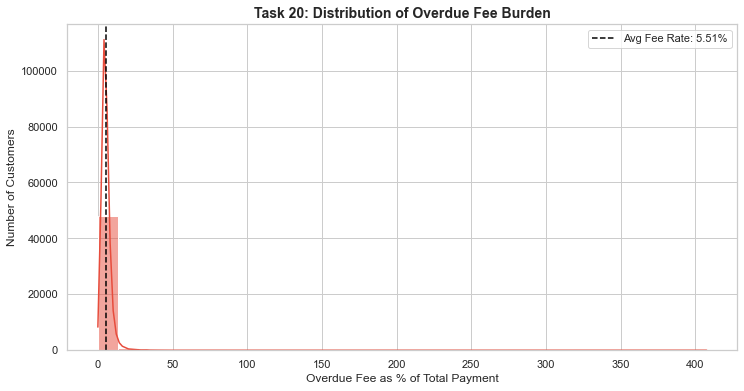

PORTFOLIO REVENUE HEALTH
---------------------------------------------
Total Amount Collected:    $12,620,730,053.00
Total Overdue Fees:        $630,299,779.00
Revenue Quality Ratio:     95.01% (Principal/Interest)
Fee Dependency Ratio:      4.99% (Penalties)


In [142]:

id_col = 'Customer_ID'
amt_col = 'Amount'
pen_col = 'Overdue_Fee'

penalty_stats = repay_data.groupby(id_col).agg({
    amt_col: 'sum',
    pen_col: 'sum'
}).reset_index()

penalty_stats['Penalty_Rate_%'] = (penalty_stats[pen_col] / penalty_stats[amt_col]) * 100

def categorize_burden(rate):
    if rate == 0: return 'Healthy (No Fees)'
    elif rate < 5: return 'Low Burden'
    else: return 'High Burden (Fee Trapped)'

penalty_stats['Burden_Category'] = penalty_stats['Penalty_Rate_%'].apply(categorize_burden)

plt.figure(figsize=(12, 6))

fee_payers = penalty_stats[penalty_stats['Penalty_Rate_%'] > 0]

sns.histplot(data=fee_payers, x='Penalty_Rate_%', bins=30, kde=True, color='#e74c3c')
plt.axvline(fee_payers['Penalty_Rate_%'].mean(), color='black', linestyle='--', 
            label=f"Avg Fee Rate: {fee_payers['Penalty_Rate_%'].mean():.2f}%")

plt.title('Task 20: Distribution of Overdue Fee Burden', fontsize=14, fontweight='bold')
plt.xlabel('Overdue Fee as % of Total Payment')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

total_cash = penalty_stats[amt_col].sum()
total_fees = penalty_stats[pen_col].sum()

print(f"PORTFOLIO REVENUE HEALTH")
print("-" * 45)
print(f"Total Amount Collected:    ${total_cash:,.2f}")
print(f"Total Overdue Fees:        ${total_fees:,.2f}")
print(f"Revenue Quality Ratio:     {((total_cash - total_fees)/total_cash)*100:.2f}% (Principal/Interest)")
print(f"Fee Dependency Ratio:      {(total_fees/total_cash)*100:.2f}% (Penalties)")

### Comparing transaction amounts for overdue vs. non-overdue loans

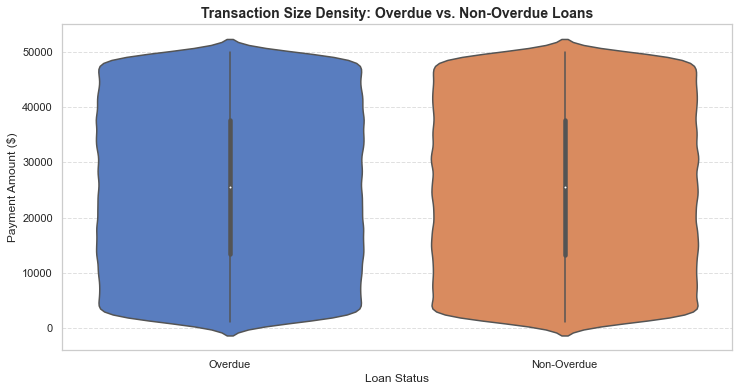

📈 Transaction Amount Comparison:
------------------------------------------------------------
Loan_Overdue_Status         mean  median          std  count
        Non-Overdue 25462.476459 25455.0 14156.105728 247912
            Overdue 25530.485451 25528.0 14131.846521 247088

Insight: Overdue loans have an average payment that is -0.27% smaller than healthy loans.


In [191]:
repay_with_status = pd.merge(repay_data, loans[['Loan_ID', 'Overdue_Amount']], on='Loan_ID', how='inner')

repay_with_status['Loan_Overdue_Status'] = repay_with_status['Overdue_Amount'].apply(
    lambda x: 'Overdue' if x > 0 else 'Non-Overdue'
)


plt.figure(figsize=(12, 6))


sns.violinplot(data=repay_with_status, x='Loan_Overdue_Status', y='Amount', 
               palette='muted', split=True)

plt.title('Transaction Size Density: Overdue vs. Non-Overdue Loans', fontsize=14, fontweight='bold')
plt.ylabel('Payment Amount ($)')
plt.xlabel('Loan Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

stats = repay_with_status.groupby('Loan_Overdue_Status')['Amount'].agg(['mean', 'median', 'std', 'count']).reset_index()

print("📈 Transaction Amount Comparison:")
print("-" * 60)
print(stats.to_string(index=False))

non_ov_avg = stats.loc[stats['Loan_Overdue_Status'] == 'Non-Overdue', 'mean'].values[0]
ov_avg = stats.loc[stats['Loan_Overdue_Status'] == 'Overdue', 'mean'].values[0]
gap = ((non_ov_avg - ov_avg) / non_ov_avg) * 100

print(f"\nInsight: Overdue loans have an average payment that is {gap:.2f}% smaller than healthy loans.")

## Master Risk List

In [190]:

master_strategy = pd.merge(behavior_data, irregularity[['Customer_ID', 'Irregularity_Score', 'Stability']], on='Customer_ID', how='left')
master_strategy = pd.merge(master_strategy, penalty_stats[['Customer_ID', 'Penalty_Rate_%', 'Burden_Category']], on='Customer_ID', how='left')

master_strategy.to_csv('Hero_FinCorp_Risk_Strategy.csv', index=False)
print("Master Strategy List generated and saved as CSV!")

Master Strategy List generated and saved as CSV!
